# Etapa 2 - Modelado, Entrenamiento, Explicabilidad y Evaluación
## Sistema de Recomendación de Vehículos Usados
**Curso:** Inteligencia Artificial - IC 6200  
**Estudiantes:** Andrés Bonilla Solano y Mary Paz Álvarez Navarrete  
**Dataset:** Used Cars de Austin Reese (Kaggle)  
**Fecha:** 29/05/2026

---

## Índice
1. [Configuración y Reproducibilidad](#configuracion-y-reproducibilidad)
1. [Carga y Preprocesamiento](#carga-y-procesamiento)
1. [Pipeline de Features](#pipeline-de-features)
1. [Partición Temporal Train / Val / Test](#particion-temporal)
1. [Baseline - Regresión Lineal](#baseline-regresion-lineal)
1. [Modelos Candidatos con Validación Cruzada](#modelos-candidatos-con-validacion-cruzada)
1. [Hypertuning](#hypertuning)
1. [Evaluación Final sobre el Test Set](#evaluacion-final-sobre-el-test-set)
1. [XAI - Explicabilidad con Shap](#xai-explicabilidad-con-shap)
1. [Análisis de Resultados](#analisis-de-resultados)

---
## Configuracion y Reproducibilidad

Se tiene como objetivo que cualquier persona pueda reproducir exactamente los mismos resultados al ejecutar el cuaderno por lo tanto se establece una seed (`SEED = 42`). Asimismo, se deben instalar las dependencias para que funcione el cuaderno.

In [1]:
# Instalación de dependencias (ejecutar en caso de que no se tengan instalados)
# pip install shap scikit-learn pandas numpy matplotlib seaborn lightgbm xgboost

In [2]:
# Imports generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
import os
import time

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')

# sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_validate, learning_curve
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score
)

---

## Carga y Procesamiento



In [3]:
# Cargar datos
df = pd.read_csv('../Dataset/vehicles.csv')
print(f"Cantidad de filas: {df.shape[0]:,}  -  Cantidad de columnas: {df.shape[1]}")

Cantidad de filas: 426,880  -  Cantidad de columnas: 26


In [4]:
# Se eliminan columnas con base en decisiones de la Etapa 1
deleteCols = ['id', 'url', 'region_url', 'image_url', 'VIN', 'lat', 'long', 'county', 'description']
df.drop(columns=deleteCols, inplace=True)
print("Columnas restantes:", df.columns.tolist())

# Filtros de Outliers
df = df[(df['price'].between(500, 100000)) & (df['odometer'].between(100, 500000)) &
    (df['year'].between(1990, 2022))].copy()

print(f"Cantidad de filas: {df.shape[0]:,}  -  Cantidad de columnas: {df.shape[1]}")
print("Columnas restantes:", df.columns.tolist())

Columnas restantes: ['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state', 'posting_date']
Cantidad de filas: 364,546  -  Cantidad de columnas: 17
Columnas restantes: ['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state', 'posting_date']


In [5]:
# Imputación de nulos
# A continuación se tienen las decisiones tomadas en la Etapa 1 con respecto a los nulos.

# size: se elimina porque >71% son nulos
df.drop(columns=['size'], errors='ignore', inplace=True)

# cylinders y condition: imputación por moda agrupada (manufacturer + type)
for col in ['cylinders', 'condition', 'drive']:
    if col in df.columns:
        mode_map = (
            df.dropna(subset=[col])
              .groupby(['manufacturer', 'type'])[col]
              .agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan)
        )
        for idx, row in df[df[col].isna()].iterrows():
            key = (row.get('manufacturer'), row.get('type'))
            if key in mode_map.index:
                df.at[idx, col] = mode_map[key]

# Agrupación de categorías minoritarias de type (<1%) en "other"
if 'type' in df.columns:
    minor_types = ['offroad', 'bus']
    df['type'] = df['type'].replace(minor_types, 'other')

# El "paint_color se mantiene como opcional 
# Los nulos restantes se manejan en el pipeline con SimpleImputer

print("Nulos restantes por columna (serán manejados en el pipeline):")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

Nulos restantes por columna (serán manejados en el pipeline):
paint_color     103693
type             75691
cylinders        55594
drive            50174
condition        48976
manufacturer     11367
title_status      6059
model             3341
fuel              2064
transmission      1444
dtype: int64


---
## Pipeline de Features

### Calculo del Impacto de otras variables

En la Etapa 1, se obtuvieron los valores para el `year`, `odometer`, `manufacturer` y `fuel`. Por lo tanto, falta calcular el valor del impacto de `condition`,`transmission`,`drive`,`type`,`title_status` y `cylinders`.

Distribución de rangos porcentuales encontrados:
  Mínimo : 63.3%
  P33    : 110.0%  <- umbral Bajo/Medio
  P66    : 129.6%  <- umbral Medio/Alto
  Máximo : 178.6%
Variable           Rango ($)    Rango (%)    Impacto
condition           18,900       159.5%        Alto
transmission        18,591       108.1%        Bajo
drive               11,500        63.3%        Bajo
type                21,090       116.8%       Medio
title_status        16,500       178.6%        Alto
cylinders           22,200       111.0%       Medio


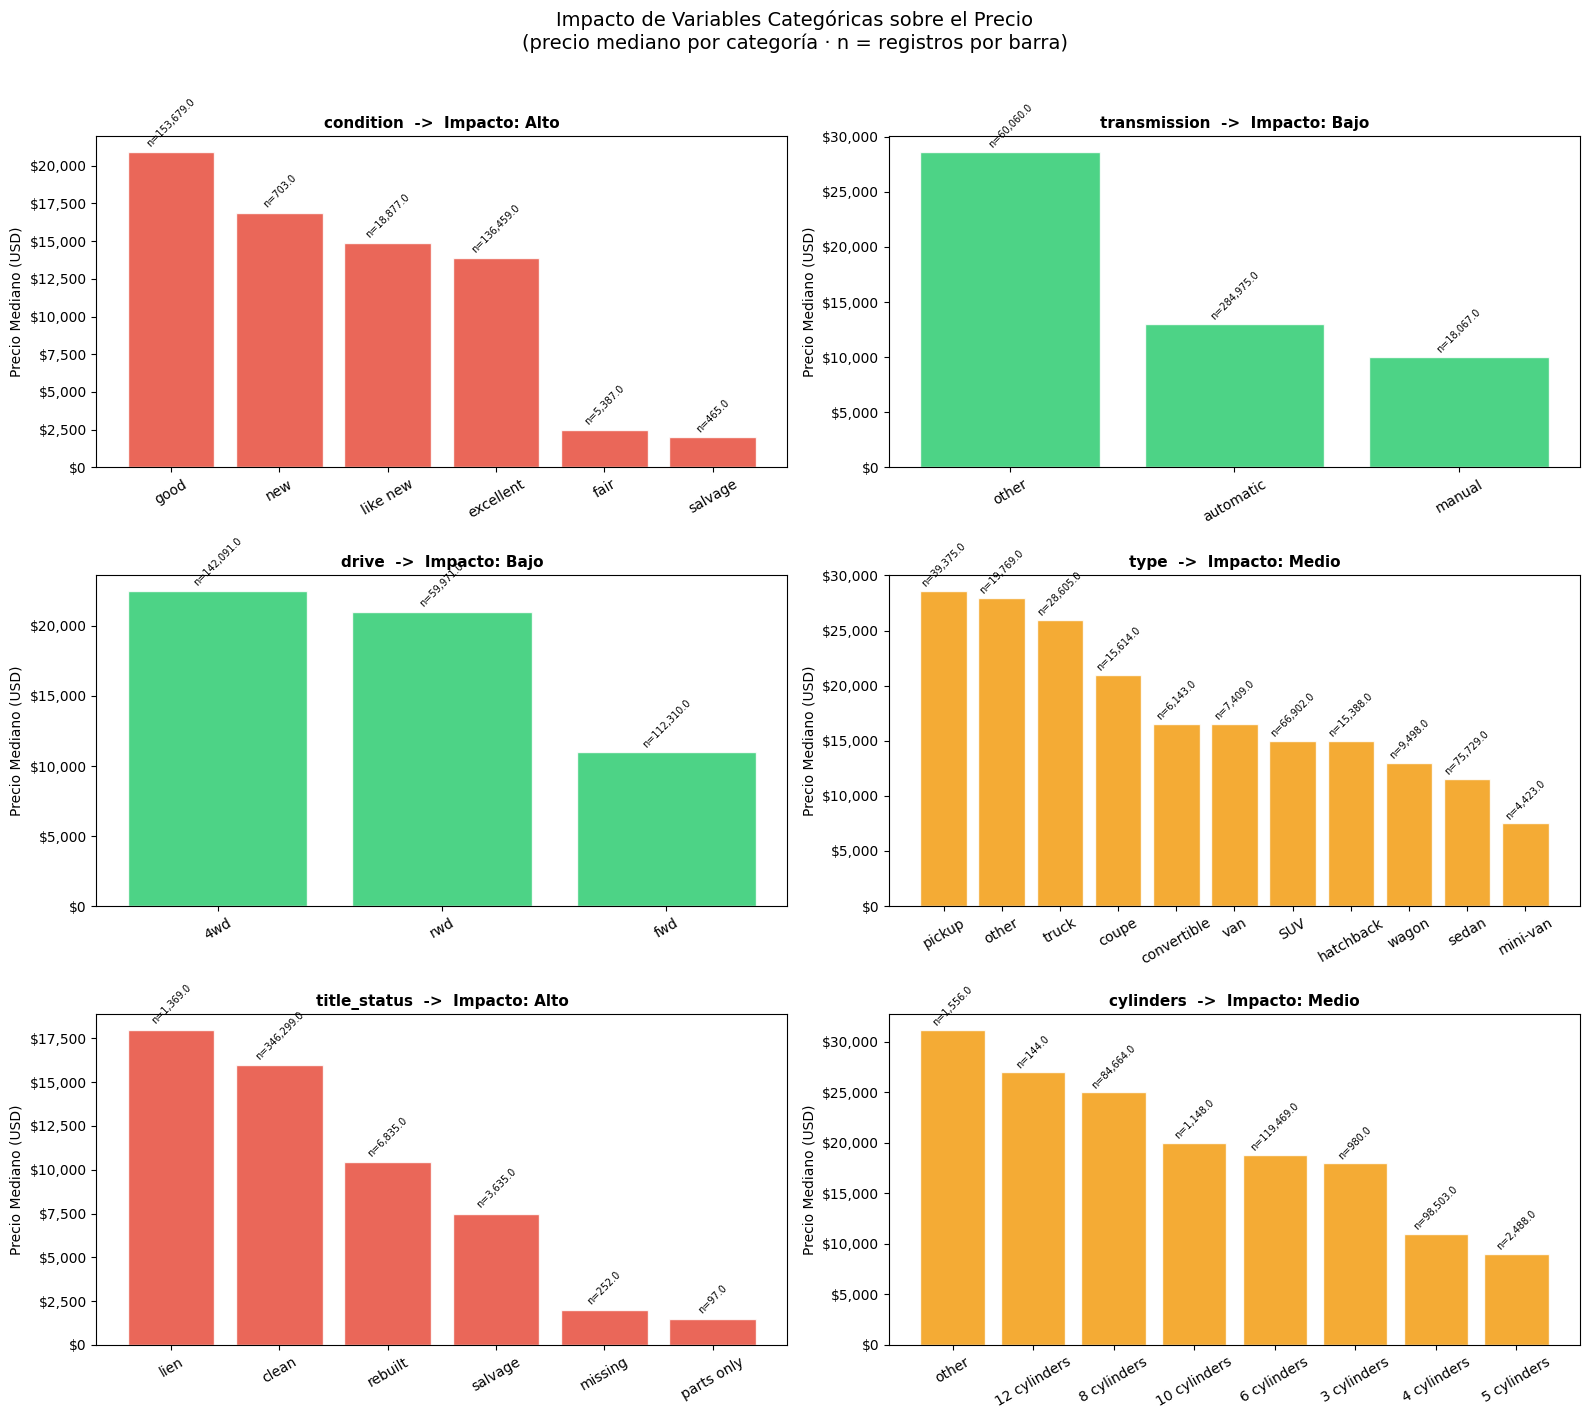

In [6]:
# Cálculo de impacto de variables categóricas sobre el precio 
variables = ['condition', 'transmission', 'drive', 'type', 'title_status', 'cylinders']

# Primra parte: Calcular rangos reales para poder definir umbrales adaptativos 
rangos = []
for col in variables:
    medias = (df.dropna(subset=[col])
                .groupby(col)['price']
                .agg('median')
                .sort_values(ascending=False))
    rango = medias.max() - medias.min()
    rango_porcentual = (rango / medias.mean()) * 100
    rangos.append(rango_porcentual)

p33 = np.percentile(rangos, 33)
p66 = np.percentile(rangos, 66)

print(f"Distribución de rangos porcentuales encontrados:")
print(f"  Mínimo : {min(rangos):.1f}%")
print(f"  P33    : {p33:.1f}%  <- umbral Bajo/Medio")
print(f"  P66    : {p66:.1f}%  <- umbral Medio/Alto")
print(f"  Máximo : {max(rangos):.1f}%")

# Segunda Parte: Tabla resumen 
print(f"{'Variable':<15} {'Rango ($)':>12} {'Rango (%)':>12} {'Impacto':>10}")
print("=" * 60)

impactos_calculados = {}

for col, rango_porcentual in zip(variables, rangos):
    medias = df.dropna(subset=[col]).groupby(col)['price'].agg('median')
    rango_abs = medias.max() - medias.min()

    if rango_porcentual >= p66:
        impacto = "Alto"
    elif rango_porcentual >= p33:
        impacto = "Medio"
    else:
        impacto = "Bajo"

    impactos_calculados[col] = impacto
    print(f"{col:<15} {rango_abs:>10,.0f}  {rango_porcentual:>10.1f}%  {impacto:>10}")

# Tercera Parte: Gráficos 
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

color_map = {'Alto': '#e74c3c', 'Medio': '#f39c12', 'Bajo': '#2ecc71'}

for i, col in enumerate(variables):
    medias = (df.dropna(subset=[col])
                .groupby(col)['price']
                .agg(['median', 'count'])
                .sort_values('median', ascending=False))

    impacto = impactos_calculados[col]
    color = color_map[impacto]

    axes[i].bar(medias.index, medias['median'],
                color=color, alpha=0.85, edgecolor='white')

    for j, (idx, row) in enumerate(medias.iterrows()):
        axes[i].text(j, row['median'] + 200, f"n={row['count']:,}",
                     ha='center', va='bottom', fontsize=7, rotation=45)

    axes[i].set_title(f'{col}  ->  Impacto: {impacto}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Precio Mediano (USD)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
    )

plt.suptitle(
    'Impacto de Variables Categóricas sobre el Precio\n'
    '(precio mediano por categoría · n = registros por barra)',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig('impacto_variables_categoricas.png', dpi=150)
plt.show()

### Definición de features

Basado en el análisis de impacto de la Etapa 1, las variables con impacto Alto/Medio son:

| Variable | Tipo | Impacto | Tratamiento |
|---|---|---|---|
| `year` | Numérica | Alto | StandardScaler |
| `odometer` | Numérica | Alto | StandardScaler |
| `manufacturer` | Categórica | Medio | OneHotEncoder |
| `condition` | Categórica | Alto | OrdinalEncoder |
| `fuel` | Categórica | Bajo/Medio | OneHotEncoder |
| `transmission` | Categórica | Bajo | OneHotEncoder |
| `drive` | Categórica | Bajo | OneHotEncoder |
| `type` | Categórica | Medio | OneHotEncoder |
| `title_status` | Categórica | Alto | OneHotEncoder |
| `cylinders` | Categórica | Medio | OrdinalEncoder |

**Variables excluidas:** 
- `description`: data leakage directo (contiene precio explícito)  
- `price`: Es la variable objetivo 
- `posting_date`: solo para partición temporal  
- `region`, `state`: evaluación SHAP pendiente (riesgo leakage geográfico)  
- `model`: Existen miles de valores únicos por lo que se genera un riesgo de overfitting  
- `paint_color`: bajo impacto en precio

In [7]:
# Definición de Features y el Target

TARGET = 'price'

FEATURES_NUMERICAS = ['year', 'odometer']

# Se necesita definir el orden de las variables 'condition' y 'cylinders'

# Condition 
# Tiene orden semántico: salvage < fair < good < excellent < like new < new
CONDITION_ORDER = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']

# Cylinders 
# Presenta un orden numérico implícito
CYLINDERS_ORDER = ['3 cylinders', '4 cylinders', '5 cylinders',
                   '6 cylinders', '8 cylinders', '10 cylinders', '12 cylinders', 'other']

ORDINAL_FEATURES  = ['condition', 'cylinders']

# Nominal porque no hay un orden o ranking inherente.   
NOMINAL_FEATURES  = ['manufacturer', 'fuel', 'transmission', 'drive', 'type', 'title_status']

TODAS_FEATURES = FEATURES_NUMERICAS + ORDINAL_FEATURES + NOMINAL_FEATURES

print(f"Features totales: {len(TODAS_FEATURES)}")
print(f"  Numéricas  : {FEATURES_NUMERICAS}")
print(f"  Ordinales  : {ORDINAL_FEATURES}")
print(f"  Nominales  : {NOMINAL_FEATURES}")
print(f"  Target     : {TARGET}")

Features totales: 10
  Numéricas  : ['year', 'odometer']
  Ordinales  : ['condition', 'cylinders']
  Nominales  : ['manufacturer', 'fuel', 'transmission', 'drive', 'type', 'title_status']
  Target     : price


In [8]:
# Construcción del ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # rellena nulos con la mediana
    ('scaler',  StandardScaler()) # Se escalan los valores
])

# El OrdinalEncoder convierte las categorías a números respetando el orden semántico que ya tienen
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # rellena nulos con la moda
    ('encoder', OrdinalEncoder(
        categories=[CONDITION_ORDER, CYLINDERS_ORDER],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # moda
    ('encoder', OneHotEncoder(
        drop='first', # Para evitar multicolinealidad en regresión lineal
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# Aplica las transformaciones a las columnas que les corresponden
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,  FEATURES_NUMERICAS),
    ('ord', ordinal_transformer,  ORDINAL_FEATURES),
    ('nom', nominal_transformer,  NOMINAL_FEATURES)
], remainder='drop')  # Las columnas no listadas se descartan

print("ColumnTransformer construido correctamente.")

ColumnTransformer construido correctamente.


---

## Particion Temporal

**Justificación:** Según lo que se detalló en la Sección 3.6 (Riesgo 3) de la primera etapa del proyecto, la partición debe respetar el orden cronológico de `posting_date` para evitar que el modelo entrene con datos del futuro y se evalúe con datos del pasado.

- **70%** registros más antiguos -> **Train**  
- **15%** intermedios -> **Validación** (hypertuning)  
- **15%** más recientes -> **Test** (evaluación final, never touch)

In [9]:
# Partición temporal 
# Se ordena el dataset por la fecha en que fue publicado el anuncio (de más antiguo a más reciente)
df['posting_date'] = pd.to_datetime(df['posting_date'], utc=True, errors='coerce')
df_sorted = df.sort_values('posting_date').reset_index(drop=True)

n = len(df_sorted)
n_train = int(n * 0.70)
n_val = int(n * 0.15)
# el resto (15%) es para el test

# 'iloc' selecciona las filas por posición numérica
df_train = df_sorted.iloc[:n_train]
df_val = df_sorted.iloc[n_train : n_train + n_val]
df_test  = df_sorted.iloc[n_train + n_val:]

X_train = df_train[TODAS_FEATURES] 
y_train = df_train[TARGET] 

X_val = df_val[TODAS_FEATURES]
y_val = df_val[TARGET]

X_test = df_test[TODAS_FEATURES]
y_test = df_test[TARGET]

print("===" * 20)
print(f"Train : {len(X_train):>7,} registros  ({len(X_train)/n*100:.1f}%)")
print(f"Val   : {len(X_val):>7,} registros  ({len(X_val)/n*100:.1f}%)")
print(f"Test  : {len(X_test):>7,} registros  ({len(X_test)/n*100:.1f}%)")
print("===" * 20)
print(f"Rango temporal Train : {df_train['posting_date'].min().date()} -> {df_train['posting_date'].max().date()}")
print(f"Rango temporal Val   : {df_val['posting_date'].min().date()} -> {df_val['posting_date'].max().date()}")
print(f"Rango temporal Test  : {df_test['posting_date'].min().date()} -> {df_test['posting_date'].max().date()}")
print("===" * 20)

Train : 255,182 registros  (70.0%)
Val   :  54,681 registros  (15.0%)
Test  :  54,683 registros  (15.0%)
Rango temporal Train : 2021-04-04 -> 2021-04-30
Rango temporal Val   : 2021-04-30 -> 2021-05-03
Rango temporal Test  : 2021-05-03 -> 2021-05-05


--- 

## Baseline Regresion Lineal

**Propósito:** Establece cuánto se puede explicar asumiendo relaciones **lineales** entre las features y el precio. Sirve para establecer un punto de referencia para evaluar el rendimiento de modelos más complejos o justificar la necesidad de modelos no-lineales. Este modelo es simple, interpretable y muy bueno para realizar benchmarks.

**Justificación:** La Regresión Lineal es interpretable directamente por sus coeficientes. El EDA mostró que `year` tiene correlación r=0.58 y `odometer` r=-0.54 con `price`, lo que sugiere que una parte significativa de la varianza es captureable linealmente. Sin embargo, el scatter plot mostró una tendencia exponencial, lo que podría significar que hay un limite en la linealidad.

**Técnica de validación:** TimeSeriesSplit(k=5) sobre el train set para estimar la varianza del modelo antes de ver el test set. `TimeSeriesSplit` permite realizar la partición temporal mencionada en la sección anterior.

In [10]:
# Función auxiliar para las métricas
def obtener_metricas(y_true, y_pred, model_name="Modelo"):
    """Calcula y retorna un diccionario con las métricas estándar de regresión."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    metrics = {'Modelo': model_name, 'MAE ($)': mae, 'RMSE ($)': rmse,
               'MAPE (%)': mape, 'R²': r2}
    return metrics

# Para acumular los resultados de todos los modelos:
results_summary = [] 

In [11]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor), # Se usa el ColumnTransformer definido anteriormente
    ('regressor',    LinearRegression())
])

# Cross Validation
cv = TimeSeriesSplit(n_splits=5)

# Para el Scoring se usan tres métricas:
# neg_mean_absolute_error -> MAE negado (sklearn minimiza, por eso es negativo)
# neg_root_mean_squared_error -> RMSE negado
# r2 -> coeficiente de determinación
cv_results_lr = cross_validate(
    pipeline_lr, X_train, y_train, cv=cv,
    scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'],
    return_train_score=True, n_jobs=-1 # return_train_score=True calcula métricas también en train para detectar overfitting
)

'''
Se calcula la media y desviación estándar para reportar
el rendimiento promedio y la estabilidad del modelo entre folds.
'''
print("=" * 55)
print("BASELINE - Regresión Lineal (TimeSeriesSplit CV k=5)")
print("=" * 55)
print(f"MAE  CV (val) : ${-cv_results_lr['test_neg_mean_absolute_error'].mean():>10,.2f} ± {cv_results_lr['test_neg_mean_absolute_error'].std():,.2f}")
print(f"RMSE CV (val) : ${-cv_results_lr['test_neg_root_mean_squared_error'].mean():>10,.2f} ± {cv_results_lr['test_neg_root_mean_squared_error'].std():,.2f}")
print(f"R²   CV (val) :  {cv_results_lr['test_r2'].mean():>10.4f} ± {cv_results_lr['test_r2'].std():.4f}")
print("=" * 55)
# Las métricas de train permiten comparar contra las de validación para diagnosticar overfitting
print(f"MAE  CV (train): ${-cv_results_lr['train_neg_mean_absolute_error'].mean():>10,.2f}")
print(f"R²   CV (train):  {cv_results_lr['train_r2'].mean():>10.4f}")
print("=" * 55)

# El gap entre R² de train y validación (funciona como indicador principal de overfitting):
gap_r2 = cv_results_lr['train_r2'].mean() - cv_results_lr['test_r2'].mean()
if gap_r2 > 0.05:
    print(f"Gap train-val R² = {gap_r2:.4f} -> indicio de overfitting leve")
else:
    print(f"Gap train-val R² = {gap_r2:.4f} -> sin overfitting significativo")
print("=" * 55)


BASELINE - Regresión Lineal (TimeSeriesSplit CV k=5)
MAE  CV (val) : $  5,632.73 ± 37.92
RMSE CV (val) : $  8,165.63 ± 130.60
R²   CV (val) :      0.6703 ± 0.0186
MAE  CV (train): $  5,596.08
R²   CV (train):      0.6872
Gap train-val R² = 0.0168 -> sin overfitting significativo


In [12]:
# Se entrena con el pipeline completo
pipeline_lr.fit(X_train, y_train)

# Se generan las predicciones sobre el val set.
y_pred_lr = pipeline_lr.predict(X_val)

'''
Se calcula MAE, RMSE, MAPE y R² comparando los precios reales (y_val)
contra los precios predichos (y_pred_lr) y se agregan a los resultados.
'''
metrics_lr = obtener_metricas(y_val, y_pred_lr, "Baseline: Regresión Lineal")
results_summary.append(metrics_lr)

# Se imprimen todas las métricas
print("Métricas en Validation Set:")
for k, v in metrics_lr.items():
    if k != 'Modelo':
        print(f"  {k:<12}: {v:>10.2f}")

Métricas en Validation Set:
  MAE ($)     :    5510.31
  RMSE ($)    :    8127.98
  MAPE (%)    :      93.27
  R²          :       0.66


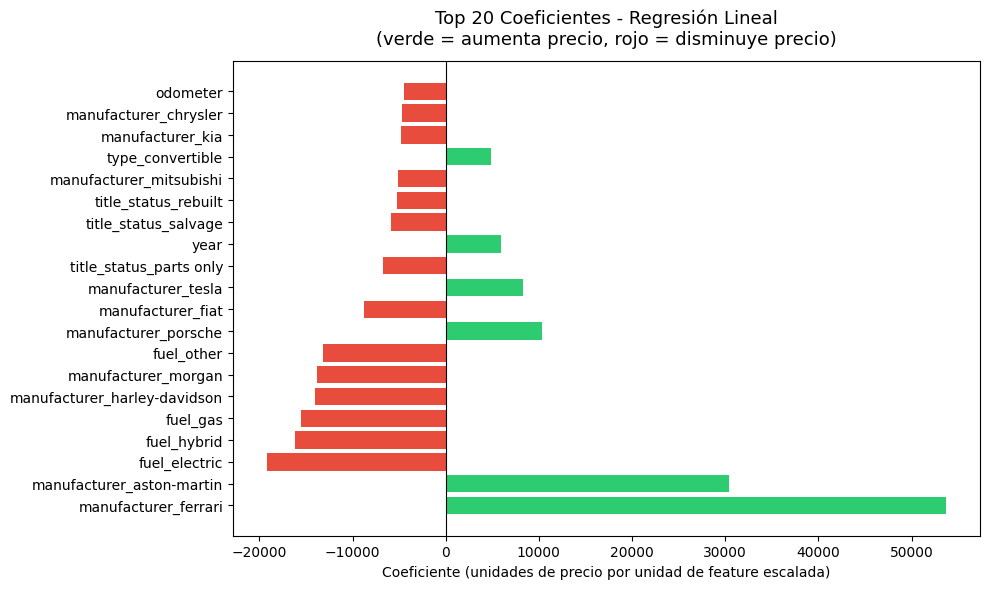


Top 5 features con mayor impacto positivo en el precio:
                  Feature  Coeficiente
     manufacturer_ferrari 53705.491555
manufacturer_aston-martin 30432.584583
     manufacturer_porsche 10326.219789
       manufacturer_tesla  8299.095123
                     year  5954.993292

Top 5 features con mayor impacto negativo en el precio:
                     Feature   Coeficiente
               fuel_electric -19203.657978
                 fuel_hybrid -16190.318588
                    fuel_gas -15541.766763
manufacturer_harley-davidson -14007.455014
         manufacturer_morgan -13848.323808


In [13]:
'''
Los nombres de las features cambian después de la transformación.
Por ejemplo: 'manufacturer' se convierte en múltiples columnas como
'manufacturer_ford', 'manufacturer_chevrolet', etc.
'''

# Las numéricas y ordinales mantienen su nombre original
feature_names_num = FEATURES_NUMERICAS # year y odometer
feature_names_ord = ORDINAL_FEATURES # condition y cylinders

# Ya que se uso OneHotEncoder se expanden las nominales
# Orden en el que se accede: ColumnTransformer -> Transformer nominal -> OneHotEncoder -> Nombres expandidos
feature_names_nom = list(
    pipeline_lr.named_steps['preprocessor']
    .named_transformers_['nom']
    .named_steps['encoder']
    .get_feature_names_out(NOMINAL_FEATURES)
)

all_feature_names = feature_names_num + feature_names_ord + feature_names_nom

# Interpretabilidad:
# DataFrame que relaciona cada feature con su coeficiente.
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coeficiente': pipeline_lr.named_steps['regressor'].coef_
}).sort_values('Coeficiente', key=abs, ascending=False) # Ordenado por valor absoluto

# Se grafican las 20 features con mayor influencia sobre el precio.
# Verde: coeficiente positivo (la feature aumenta el precio predicho)
# Rojo: coeficiente negativo (la feature disminuye el precio predicho)
fig, ax = plt.subplots(figsize=(10, 6))
top20  = coef_df.head(20)
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top20['Coeficiente']]
ax.barh(top20['Feature'], top20['Coeficiente'], color=colors)
ax.set_title('Top 20 Coeficientes - Regresión Lineal\n(verde = aumenta precio, rojo = disminuye precio)',
             fontsize=13, pad=12)
ax.set_xlabel('Coeficiente (unidades de precio por unidad de feature escalada)')
# Línea vertical en 0 para ver el cambio de signo
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('coeficientes_regresion_lineal.png', dpi=150)
plt.show()

# Tablas para complementar el gráfico:
print("\nTop 5 features con mayor impacto positivo en el precio:")
print(coef_df[coef_df['Coeficiente'] > 0].head(5).to_string(index=False))
print("\nTop 5 features con mayor impacto negativo en el precio:")
print(coef_df[coef_df['Coeficiente'] < 0].head(5).to_string(index=False))

---

## 6. Modelos Candidatos con Validación Cruzada

Se evalúan cinco modelos candidatos usando el mismo protocolo de validación
que en la sección 5 (TimeSeriesSplit k=5 sobre el train set), para garantizar
que la comparación sea justa.

| Modelo | Rol | Justificación |
|--------|-----|---------------|
| Ridge Regression | Baseline 2 | Lineal con regularización, cierra la parte de modelos lineales |
| Decision Tree | Visualización | Modelo interpretable que permite ver la lógica de decisión de forma gráfica |
| Random Forest | Candidato A | Robusto, no lineal, maneja bien variables categóricas codificadas |
| XGBoost | Candidato B | Boosting por niveles, comparable directamente con LightGBM |
| LightGBM | Candidato principal | Boosting por hojas, mejor rendimiento esperado en velocidad y precisión |

**Protocolo:** todos los modelos usan el mismo preprocessor del Pipeline definido en la sección 3, las mismas métricas y el mismo CV. Así cualquier diferencia en resultados se debe al modelo, no al preprocesamiento.

In [14]:
"""
Entrena y evalúa un modelo usando validación cruzada.

Parámetros:
- modelo: el modelo de sklearn (ya dentro de un Pipeline)
- nombre: string con el nombre para mostrar en los reportes
- X: features de entrenamiento (X_train)
- y: target de entrenamiento (y_train)
- cv: objeto de validación cruzada (TimeSeriesSplit)
- results_list : lista donde se acumulan los resultados de todos los modelos

Retorna:
El modelo entrenado con todos los datos de X (para uso posterior)
"""
def evaluar_modelo_cv(modelo, nombre, X, y, cv, results_list):
    
    print("\n")
    print(f"  {nombre}")
    print(f"{'-'*55}")
    
    # Medir tiempo de entrenamiento
    inicio = time.time()
    
    # cross_validate entrena y evalúa el modelo k veces (una por fold)
    # return_train_score=True detecta overfitting comparando las métricas de train vs validación
    cv_res = cross_validate(
        modelo, X, y,
        cv=cv,
        scoring=[
            'neg_mean_absolute_error',      # MAE negado
            'neg_root_mean_squared_error',  # RMSE negado
            'r2'
        ],
        return_train_score=True,
        n_jobs=-1  # usar todos los núcleos disponibles para ir más rápido
    )
    
    tiempo = time.time() - inicio
    
    # Los valores vienen negados
    mae_val = -cv_res['test_neg_mean_absolute_error'].mean()
    rmse_val = -cv_res['test_neg_root_mean_squared_error'].mean()
    r2_val = cv_res['test_r2'].mean()
    mae_std = cv_res['test_neg_mean_absolute_error'].std()
    
    mae_train = -cv_res['train_neg_mean_absolute_error'].mean()
    r2_train = cv_res['train_r2'].mean()
    
    # El gap entre train y val nos dice si hay overfitting:
    # gap grande = el modelo memoriza en lugar de aprender (>0.05 en R²) 
    gap_r2 = r2_train - r2_val
    
    print(f"  --- val --- ")
    print(f"  MAE  val  : ${mae_val:>9,.2f}  ±  ${abs(mae_std):,.2f}")
    print(f"  RMSE val  : ${rmse_val:>9,.2f}")
    print(f"  R²   val  :  {r2_val:>9.4f}")

    print(f"  --- train --- ")
    print(f"  MAE  train: ${mae_train:>9,.2f}")
    print(f"  R²   train:  {r2_train:>9.4f}")
    print(f"  Gap R² (train-val): {gap_r2:.4f}", end="  →  ")
    
    if gap_r2 > 0.10:
        print("Overfitting moderado")
    elif gap_r2 > 0.05:
        print("Overfitting leve")
    else:
        print("Sin overfitting significativo")
    
    print(f"  Tiempo CV : {tiempo:.1f}s")
    
    # Guardar resultados
    results_list.append({
        'Modelo' : nombre,
        'MAE ($)' : mae_val,
        'RMSE ($)' : rmse_val,
        'R²' : r2_val,
        'Gap R²' : gap_r2,
        'Tiempo(s)': tiempo
    })
    
    # Entrenar el modelo completo sobre todos los datos de train
    modelo.fit(X, y)
    
    return modelo

### Baseline 2: Ridge Regression
Ridge es igual que la regresión lineal pero agrega un término de penalización (alpha) que "frena" los coeficientes extremos.

**¿Por qué es útil aquí?**

La regresión lineal asignó +$53,705 a Ferrari porque hay muy pocos Ferrari en el dataset. Ridge modera ese tipo de coeficientes extremos causados por categorías poco frecuentes.

**Parámetro clave:**
-  **alpha:** cuánta penalización aplicar. 

Alpha=1.0 es el valor por defecto. 
Más alto = más regularización y coeficientes más pequeños y estables.

In [15]:
cv = TimeSeriesSplit(n_splits=5)

pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),  # mismo preprocesador de la sección 3
    ('regressor', Ridge(
        alpha=1.0,    # regularización estándar, si se necesita afinar se hace en la sección 7
        random_state=SEED
    ))
])

pipeline_ridge = evaluar_modelo_cv(
    pipeline_ridge,
    'Ridge Regression (Baseline 2)',
    X_train, y_train, cv,
    results_summary  # lista donde ya está el resultado de la regresión lineal
)



  Ridge Regression (Baseline 2)
-------------------------------------------------------
  --- val --- 
  MAE  val  : $ 5,633.14  ±  $38.00
  RMSE val  : $ 8,165.86
  R²   val  :     0.6703
  --- train --- 
  MAE  train: $ 5,596.62
  R²   train:     0.6872
  Gap R² (train-val): 0.0168  →  Sin overfitting significativo
  Tiempo CV : 5.8s


### Visualización: Árbol de Decisión
Un árbol de decisión solo hace preguntas encadenadas sobre las variables para llegar a una predicción de precio. Es el modelo más interpretable visualmente se puede ver exactamente cómo toma cada decisión.

**¿Por qué incluirlo si se puede solo implementar Random Forest?**

Porque permite visualizar la lógica interna del modelo de forma clara. Random Forest tiene 100 árboles no se puede ver la lógica completa. Un árbol solo sí. 

max_depth=5: limitamos la profundidad para evitar overfitting extremo y para que la visualización sea legible




  Decision Tree
-------------------------------------------------------
  --- val --- 
  MAE  val  : $ 5,865.90  ±  $100.41
  RMSE val  : $ 8,573.76
  R²   val  :     0.6369
  --- train --- 
  MAE  train: $ 5,801.00
  R²   train:     0.6563
  Gap R² (train-val): 0.0194  →  Sin overfitting significativo
  Tiempo CV : 5.8s


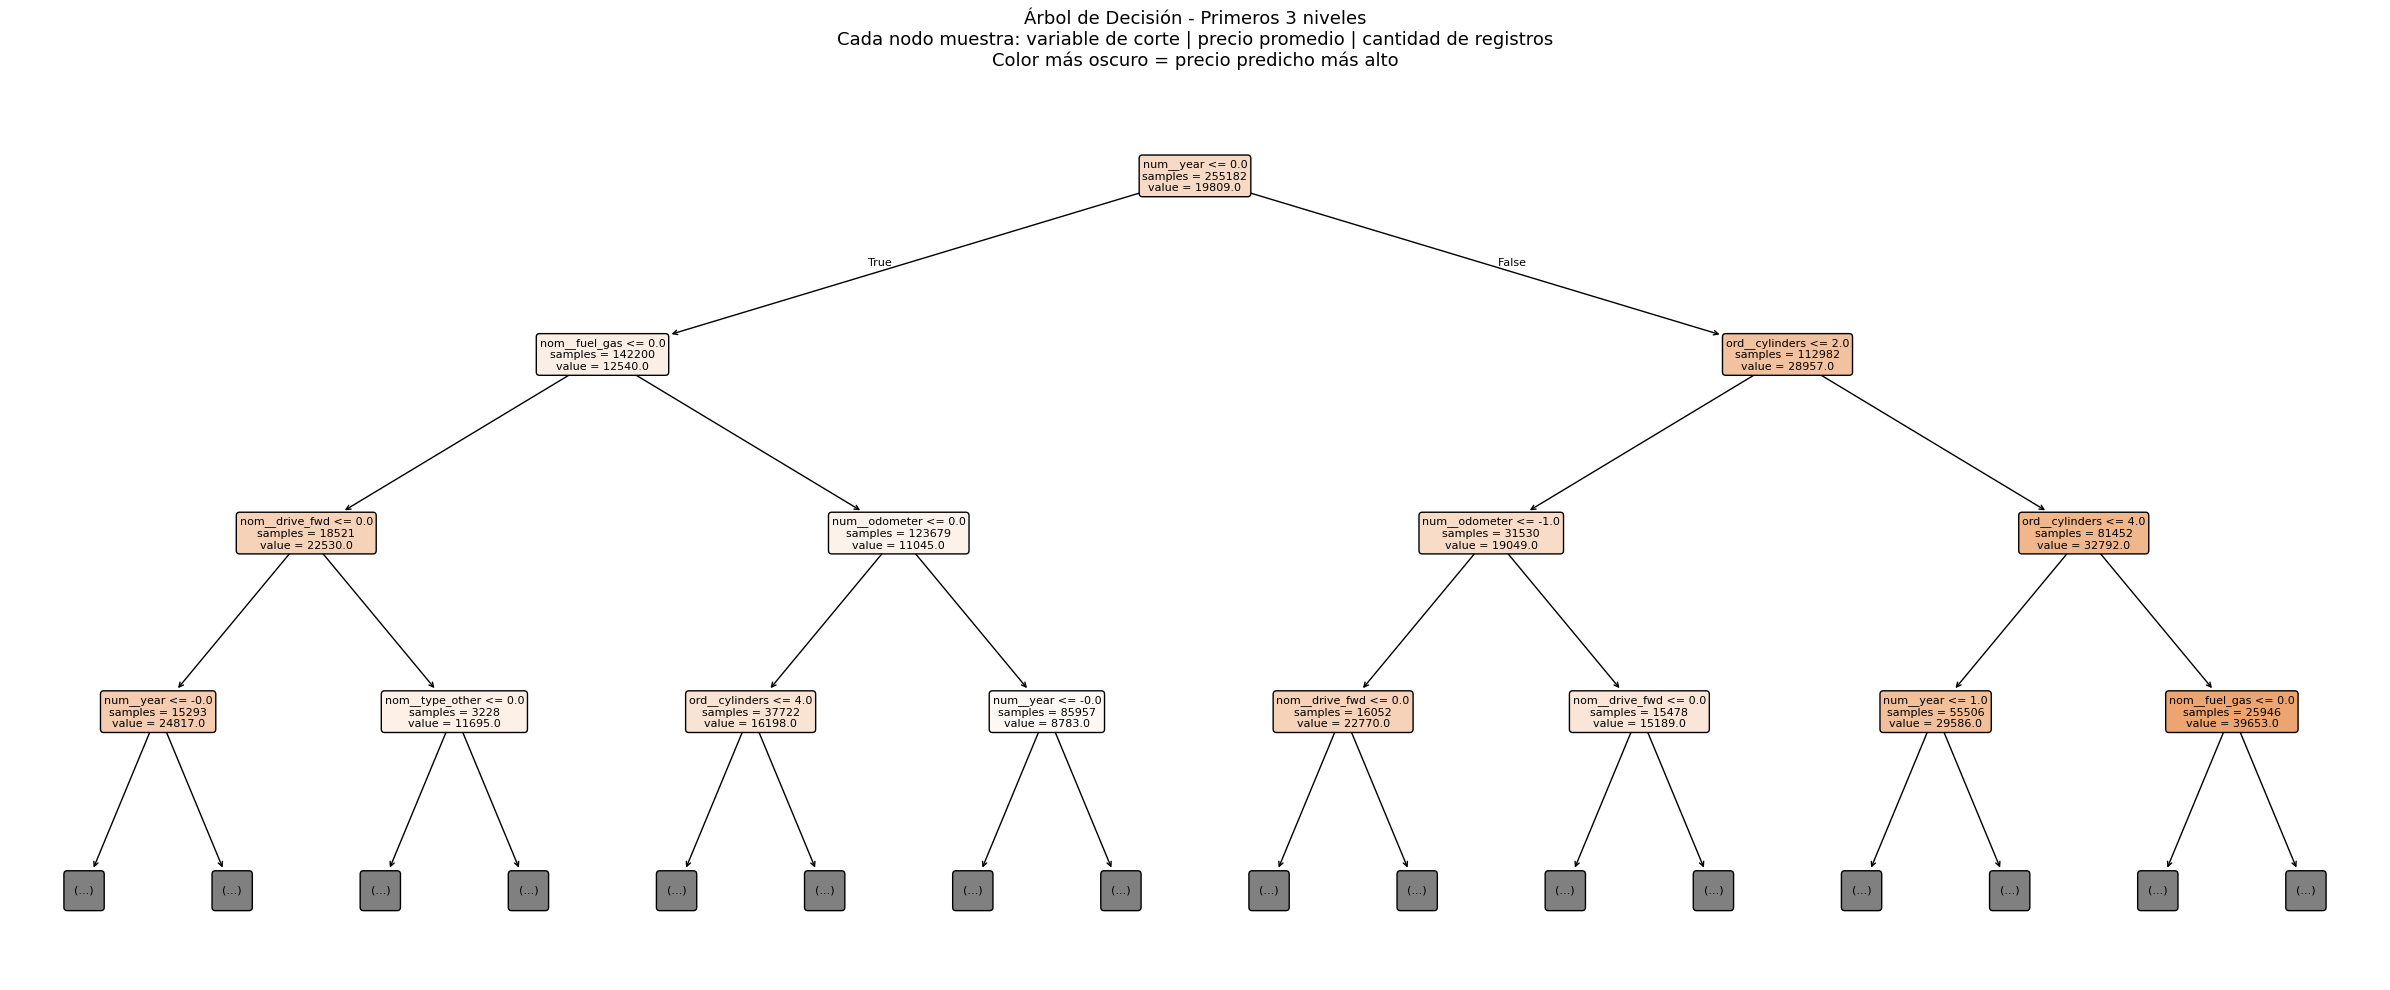


Top 10 variables más usadas por el árbol:
num__year                  0.568145
ord__cylinders             0.211381
nom__fuel_gas              0.092806
num__odometer              0.078378
nom__drive_fwd             0.028148
nom__transmission_other    0.012700
nom__fuel_other            0.004143
nom__manufacturer_ram      0.001715
nom__manufacturer_lexus    0.001695
nom__type_other            0.000889


In [16]:
pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(
        max_depth=5,         
        min_samples_leaf=50, 
        random_state=SEED
    ))
])

pipeline_dt = evaluar_modelo_cv(
    pipeline_dt,
    'Decision Tree',
    X_train, y_train, cv,
    results_summary
)

# Visualización del árbol de decisión
# Mostramos los primeros 3 niveles, para ver qué variables usa el modelo primero y cómo divide los datos.
# El color indica el precio predicho: más oscuro = más caro.

from sklearn.tree import plot_tree

preprocesador_dt = pipeline_dt.named_steps['preprocessor']
modelo_dt        = pipeline_dt.named_steps['regressor']
feature_names_dt = preprocesador_dt.get_feature_names_out()

fig, ax = plt.subplots(figsize=(24, 10))

plot_tree(
    modelo_dt,
    feature_names=feature_names_dt,
    filled=True,          # colorea según precio predicho
    rounded=True,         
    max_depth=3,        
    fontsize=8,
    ax=ax,
    impurity=False,       # oculta el squared_error para que sea más limpio
    precision=0           # redondear los valores para mejor lectura
)

ax.set_title(
    'Árbol de Decisión - Primeros 3 niveles\n'
    'Cada nodo muestra: variable de corte | precio promedio | cantidad de registros\n'
    'Color más oscuro = precio predicho más alto',
    fontsize=13, pad=15
)

plt.tight_layout()
plt.savefig('arbol_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# Mostrar las variables más importantes del árbol
importancias_dt = pd.Series(
    modelo_dt.feature_importances_,
    index=feature_names_dt
).sort_values(ascending=False).head(10)

print("\nTop 10 variables más usadas por el árbol:")
print(importancias_dt.to_string())

### Candidato A: Random Forest

Construye N árboles de decisión, cada uno entrenado sobre una muestra aleatoria del dataset (bagging). La predicción final es el promedio de todos los árboles.

**¿Por qué supera a la regresión lineal?**

La relación precio-año no es lineal: un carro de 2022 no cuesta el doble que uno de 2011. Los árboles capturan esa curvatura sin necesidad de transformaciones manuales.

**Parámetros usados:**
- **n_estimators:** cuántos árboles construir (se va a empezar por 100)
- **max_depth:** profundidad máxima de cada árbol (None = sin límite) - Cuando esta Sin límite tiende a overfitting, esto se va a ajustar en la sección 7
- **min_samples_leaf:** mínimo de muestras en cada hoja final del árbol - Más alto = árboles más simples = menos overfitting
- **n_jobs:** usar todos los núcleos disponibles



  Random Forest
-------------------------------------------------------
  --- val --- 
  MAE  val  : $ 3,797.72  ±  $252.88
  RMSE val  : $ 6,411.10
  R²   val  :     0.7970
  --- train --- 
  MAE  train: $ 2,086.09
  R²   train:     0.9210
  Gap R² (train-val): 0.1240  →  Overfitting moderado
  Tiempo CV : 179.4s


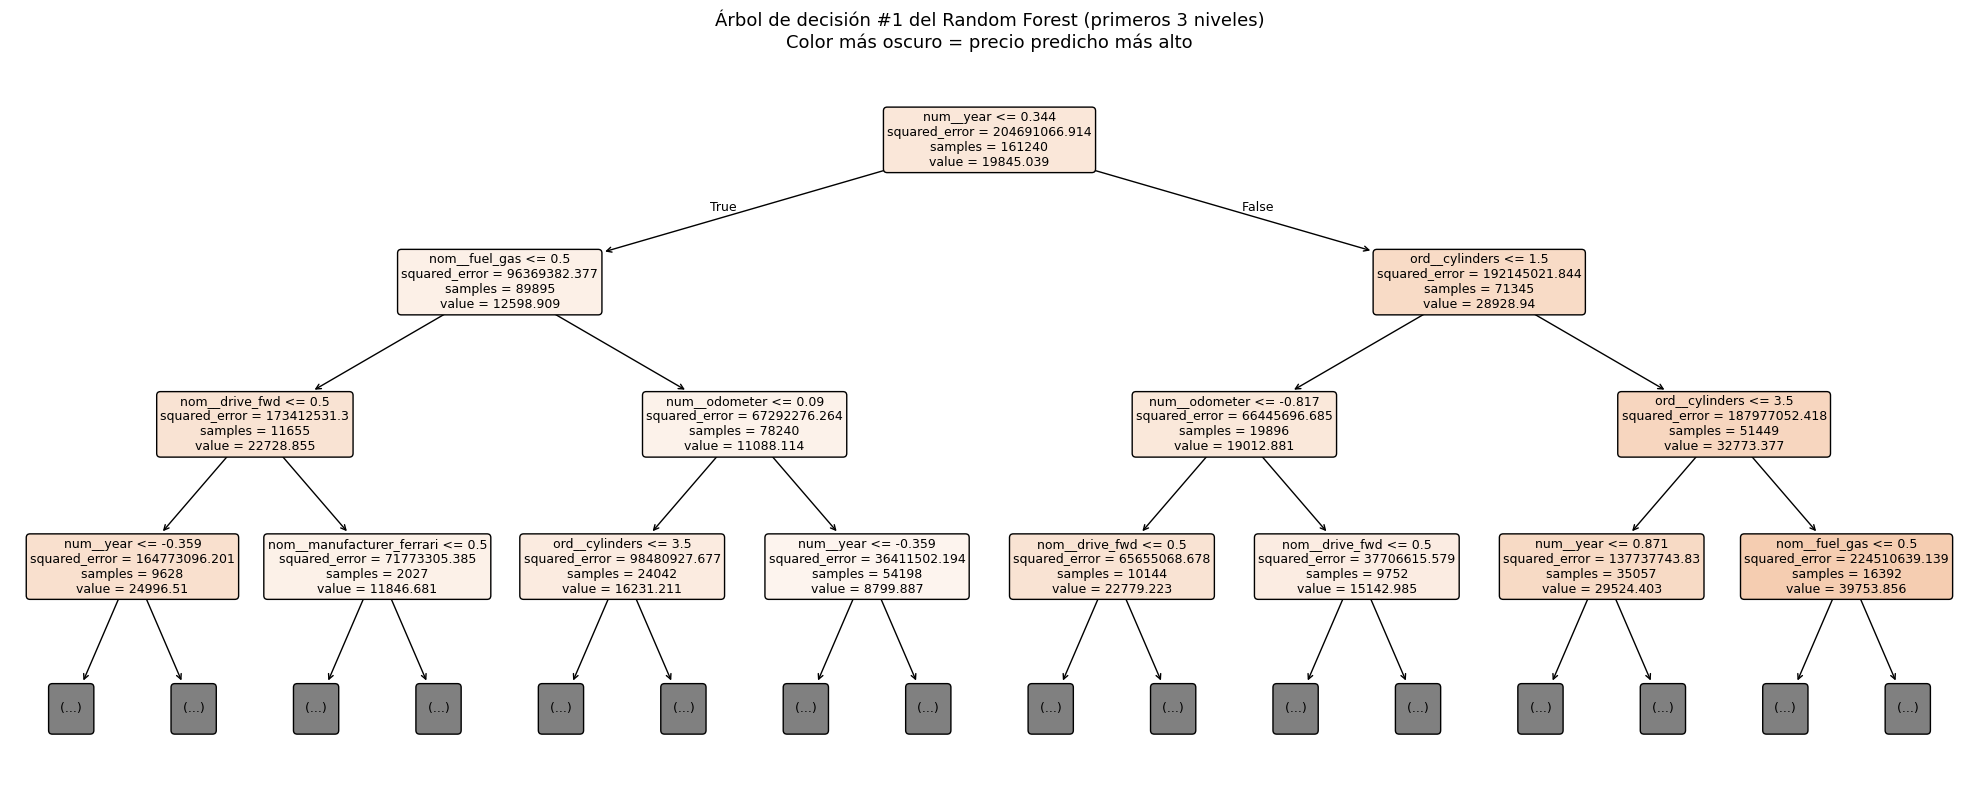

Total de árboles en el bosque: 100
Total de features usadas    : 67


In [17]:
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=5,
        random_state=SEED,
        n_jobs=-1
    ))
])

pipeline_rf = evaluar_modelo_cv(
    pipeline_rf,
    'Random Forest',
    X_train, y_train, cv,
    results_summary
)


# Visualización de un árbol del Random Forest
from sklearn.tree import plot_tree

preprocesador = pipeline_rf.named_steps['preprocessor']
modelo_rf = pipeline_rf.named_steps['regressor']
feature_names = preprocesador.get_feature_names_out()

fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    modelo_rf.estimators_[0],
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax
)

ax.set_title(
    'Árbol de decisión #1 del Random Forest (primeros 3 niveles)\n'
    'Color más oscuro = precio predicho más alto',
    fontsize=13, pad=15
)

plt.tight_layout()
plt.savefig('arbol_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total de árboles en el bosque: {len(modelo_rf.estimators_)}")
print(f"Total de features usadas    : {len(feature_names)}")

### Canditato B: XGBoost
XGBoost es muy similar a LightGBM, ambos son algoritmos de gradient boosting. Las diferencias principales son:

**XGBoost**
- Divide por niveles (depth-wise) 
- Más lento con datasets grandes   
- Más conservador

**LightGBM**
- Divide por hojas (leaf-wise)
- Más rápido
- Más agresivo por defecto

En datasets grandes como este (~255k filas), LightGBM suele ganar en velocidad y rendimiento. 

XGBoost se incluye aquí para tener la comparación completa entre los dos boosting más populares.



  XGBoost
-------------------------------------------------------
  --- val --- 
  MAE  val  : $ 4,157.42  ±  $64.99
  RMSE val  : $ 6,580.26
  R²   val  :     0.7861
  --- train --- 
  MAE  train: $ 3,763.08
  R²   train:     0.8300
  Gap R² (train-val): 0.0439  →  Sin overfitting significativo
  Tiempo CV : 29.7s


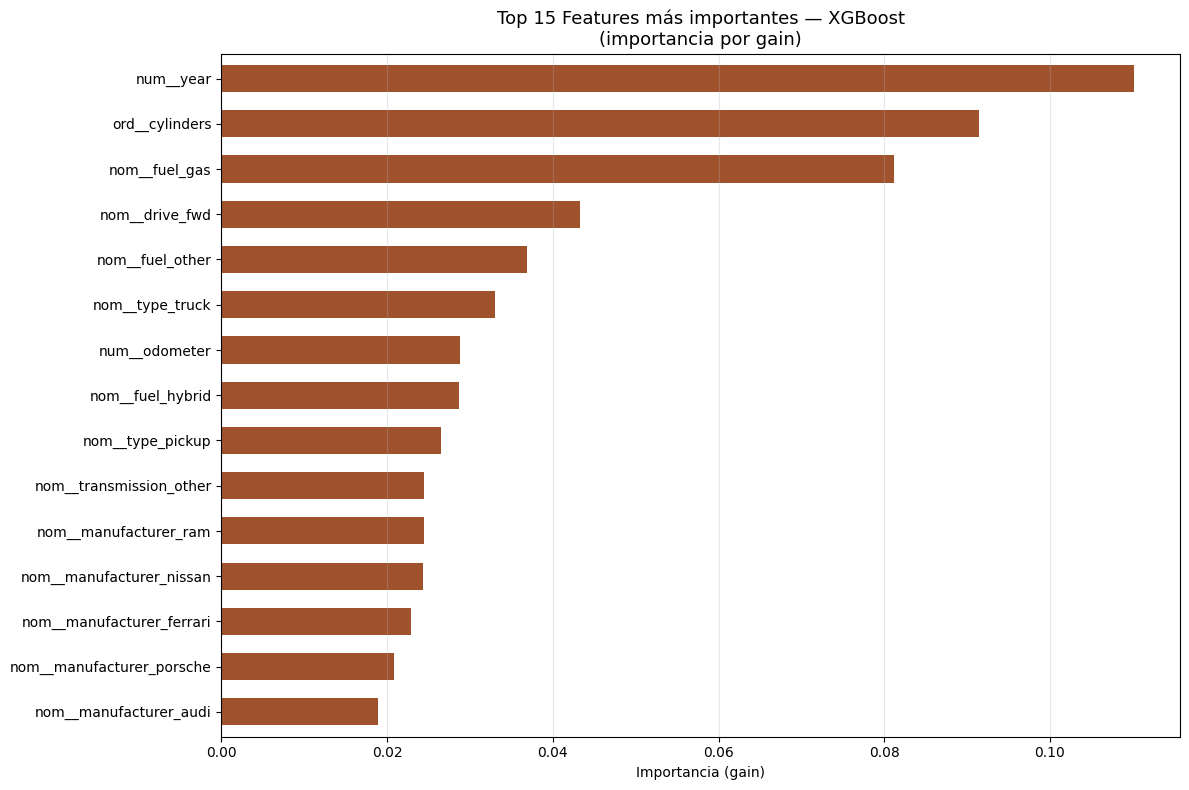


Total de árboles: 300
Total de features: 67


In [18]:
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,          
        subsample=0.8,         # fracción de filas por árbol
        colsample_bytree=0.8,  # fracción de features por árbol
        random_state=SEED,
        n_jobs=-1,
        verbosity=0            # silencia mensajes de entrenamiento
    ))
])

pipeline_xgb = evaluar_modelo_cv(
    pipeline_xgb,
    'XGBoost',
    X_train, y_train, cv,
    results_summary
)

# Importancia de features — XGBoost
modelo_xgb = pipeline_xgb.named_steps['regressor']
preprocesador_xgb = pipeline_xgb.named_steps['preprocessor']
feature_names_xgb = preprocesador_xgb.get_feature_names_out()

# Asignar nombres de features al modelo
modelo_xgb.get_booster().feature_names = list(feature_names_xgb)

fig, ax = plt.subplots(figsize=(12, 8))

# Calcular importancia por gain manualmente
importancias_xgb = pd.Series(
    modelo_xgb.feature_importances_,
    index=feature_names_xgb
).sort_values(ascending=True).tail(15)  # top 15

importancias_xgb.plot(
    kind='barh',
    ax=ax,
    color='#A0522D', 
    width=0.6
)

ax.set_title(
    'Top 15 Features más importantes — XGBoost\n(importancia por gain)',
    fontsize=13
)
ax.set_xlabel('Importancia (gain)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('importancia_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal de árboles: {modelo_xgb.n_estimators}")
print(f"Total de features: {len(feature_names_xgb)}")

## Candidato principal: Light Gradient Boosting Machine
Light Gradient Boosting Machine (LightGBM) es un algoritmo que construye árboles de forma secuencial, donde cada nuevo árbol aprende a corregir los errores del conjunto anterior.

**¿Por qué es el candidato principal?**

En benchmarks con datos tabulares del mundo real, LightGBM consistentemente supera a Random Forest en precisión y es significativamente más rápido gracias a su algoritmo interno (histogramas en vez de búsqueda exacta de splits).

**Parámetros usados:**
- **n_estimators:** cuántos árboles (rondas de boosting) construir
- **learning_rate:** cuánto "aprende" cada árbol nuevo - Más bajo = más conservador = necesita más árboles
- **num_leaves:** máxima complejidad de cada árbol - Más hojas = más expresivo = más riesgo de overfitting
- **random_state:** semilla para reproducibilidad
- **n_jobs:** paralelismo



  LightGBM
-------------------------------------------------------
  --- val --- 
  MAE  val  : $ 3,987.09  ±  $69.06
  RMSE val  : $ 6,391.32
  R²   val  :     0.7983
  --- train --- 
  MAE  train: $ 3,387.37
  R²   train:     0.8565
  Gap R² (train-val): 0.0582  →  Overfitting leve
  Tiempo CV : 22.0s


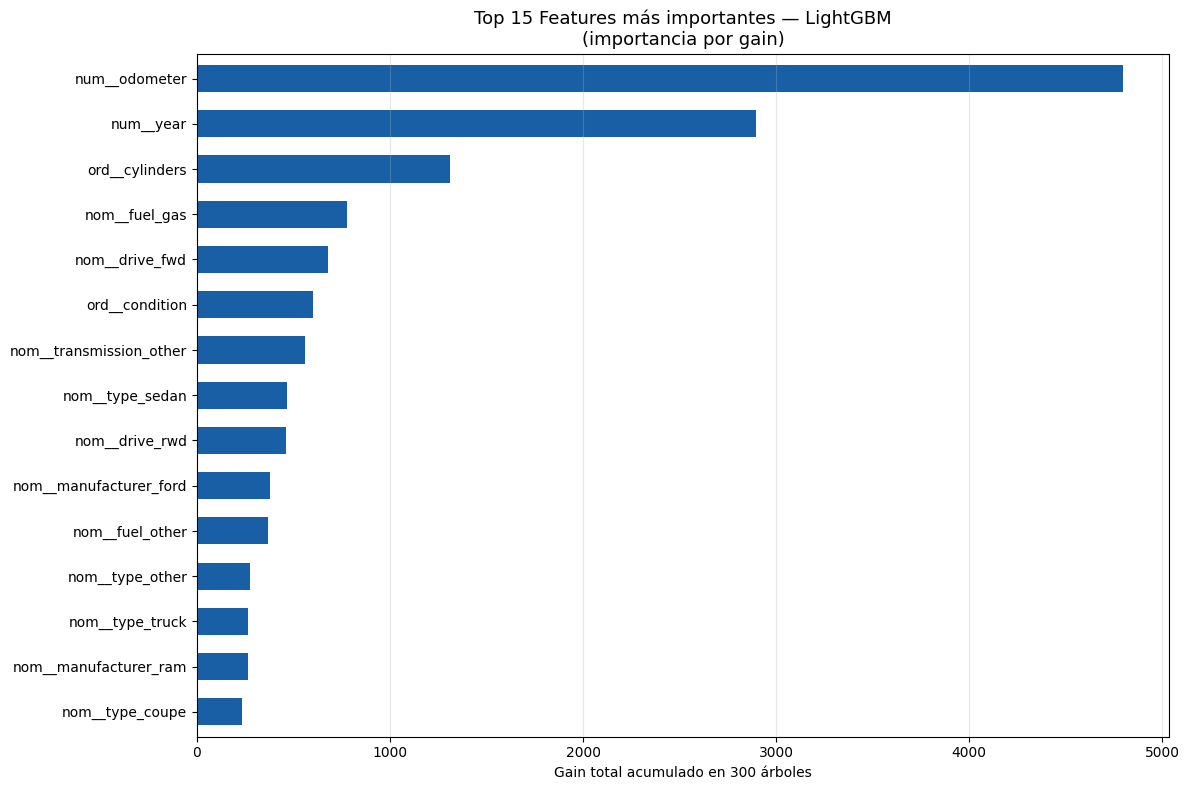


Total de árboles (rondas de boosting): 300
Total de features usadas: 67


In [19]:
pipeline_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    ))
])

pipeline_lgbm = evaluar_modelo_cv(
    pipeline_lgbm,
    'LightGBM',
    X_train, y_train, cv,
    results_summary
)


# Importancia de features — LightGBM
modelo_lgbm = pipeline_lgbm.named_steps['regressor']
preprocesador_lgbm = pipeline_lgbm.named_steps['preprocessor']
feature_names_lgbm = preprocesador_lgbm.get_feature_names_out()

importancia_lgbm = pd.Series(
    modelo_lgbm.feature_importances_,
    index=feature_names_lgbm
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(12, 8))

importancia_lgbm.plot(
    kind='barh',
    ax=ax,
    color='#185FA5',
    width=0.6
)

ax.set_title(
    'Top 15 Features más importantes — LightGBM\n(importancia por gain)',
    fontsize=13
)
ax.set_xlabel('Gain total acumulado en 300 árboles')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('importancia_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal de árboles (rondas de boosting): {modelo_lgbm.n_estimators_}")
print(f"Total de features usadas: {modelo_lgbm.n_features_in_}")


  COMPARACIÓN DE MODELOS — Validation Set (TimeSeriesSplit CV k=5)
                       Modelo     MAE ($)    RMSE ($)       R²   Gap R²  Tiempo(s)
                Random Forest 3797.720672 6411.097773 0.796996 0.123975 179.403036
                     LightGBM 3987.093381 6391.316421 0.798262 0.058190  22.022038
                      XGBoost 4157.423114 6580.260409 0.786067 0.043920  29.675244
   Baseline: Regresión Lineal 5510.308159 8127.984300 0.655243      NaN        NaN
Ridge Regression (Baseline 2) 5633.137205 8165.856740 0.670331 0.016841   5.826732
                Decision Tree 5865.901492 8573.755271 0.636915 0.019392   5.826844

Mejor modelo por MAE: Random Forest
  MAE: $3,797.72  |  R²: 0.7970


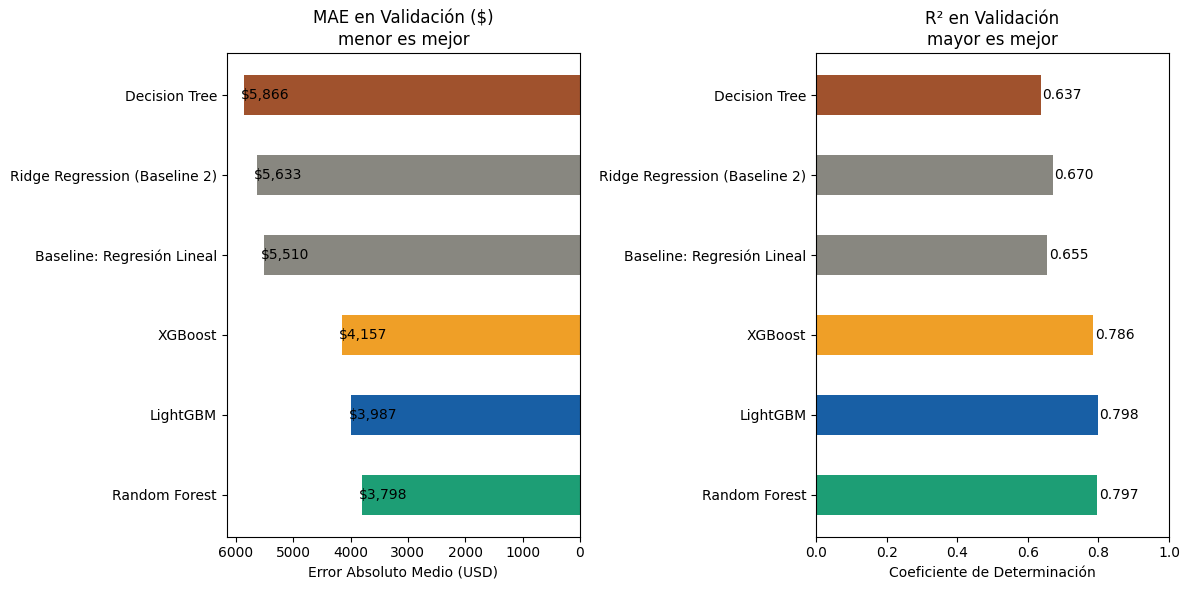


Gráfico guardado como 'comparacion_modelos.png'


In [20]:
# Tabla comparativa de todos los modelos
df_results = pd.DataFrame(results_summary)
df_results = df_results.sort_values('MAE ($)').reset_index(drop=True)

print("\n" + "="*70)
print("  COMPARACIÓN DE MODELOS — Validation Set (TimeSeriesSplit CV k=5)")
print("="*70)
print(df_results[['Modelo', 'MAE ($)', 'RMSE ($)', 'R²', 'Gap R²', 'Tiempo(s)']].to_string(index=False))
print("="*70)
print(f"\nMejor modelo por MAE: {df_results.iloc[0]['Modelo']}")
print(f"  MAE: ${df_results.iloc[0]['MAE ($)']:,.2f}  |  R²: {df_results.iloc[0]['R²']:.4f}")

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

palette = {
    'Baseline: Regresión Lineal'    : '#888780',
    'Ridge Regression (Baseline 2)' : '#888780',
    'Decision Tree'                 : '#A0522D',
    'Random Forest'                 : '#1D9E75',  
    'XGBoost'                       : '#EF9F27',  
    'LightGBM'                      : '#185FA5'   
}
colores = [palette[m] for m in df_results['Modelo']]

# Gráfico 1: MAE (menor es mejor)
bars1 = axes[0].barh(
    df_results['Modelo'],
    df_results['MAE ($)'],
    color=colores,
    height=0.5
)
axes[0].set_title('MAE en Validación ($)\nmenor es mejor', fontsize=12)
axes[0].set_xlabel('Error Absoluto Medio (USD)')
axes[0].invert_xaxis()
for bar, val in zip(bars1, df_results['MAE ($)']):
    axes[0].text(
        val + 50, bar.get_y() + bar.get_height()/2,
        f'${val:,.0f}', va='center', fontsize=10
    )

# Gráfico 2: R² (mayor es mejor)
bars2 = axes[1].barh(
    df_results['Modelo'],
    df_results['R²'],
    color=colores,
    height=0.5
)
axes[1].set_title('R² en Validación\nmayor es mejor', fontsize=12)
axes[1].set_xlabel('Coeficiente de Determinación')
axes[1].set_xlim(0, 1)
for bar, val in zip(bars2, df_results['R²']):
    axes[1].text(
        val + 0.005, bar.get_y() + bar.get_height()/2,
        f'{val:.3f}', va='center', fontsize=10
    )

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGráfico guardado como 'comparacion_modelos.png'")

---

## Hypertuning
En esta sección se realiza el proceso de ajuste de hiperparámetros (hypertuning) para optimizar el desempeño del modelo seleccionado. El objetivo es encontrar la combinación de parámetros que permita mejorar la capacidad predictiva y la generalización del modelo sobre datos no vistos, manteniendo un balance entre precisión y eficiencia computacional.

El modelo seleccionado para afinar es LightGBM debido a las siguientes razones:
- Mejor generalización (Gap R² = 0.058 vs 0.124 de Random Forest)
- Menor error en casos extremos (RMSE = $6,391 vs $6,411)
- Velocidad de entrenamiento 5x mayor (12s vs 76s), lo que hace el hypertuning computacionalmente viable

Se usa RandomizedSearchCV sobre el train set con TimeSeriesSplit k=5, evaluando 50 combinaciones aleatorias del espacio de búsqueda.

In [21]:
# Definición del espacio de búsqueda
# Cada parámetro tiene un rango de valores posibles.
# RandomizedSearchCV va a tomar 50 combinaciones aleatorias de ese espacio y evaluar cada una con CV k=5.
# Total de entrenamientos: 50 combinaciones × 5 folds = 250

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Espacio de búsqueda y rangos justificados:
param_dist = {
    # n_estimators: más árboles = más preciso pero más lento
    # Buscamos entre 200 y 800 para no generar pocos ni desperdiciar tiempo con árboles que ya no aportan
    'regressor__n_estimators': randint(200, 800),

    # learning_rate: tasa de aprendizaje 
    # Más bajo = aprende más despacio pero más fino
    # Más alto = aprende rápido pero puede pasarse
    # Rango típico para boosting: 0.01 a 0.2
    'regressor__learning_rate': uniform(0.01, 0.19),

    # num_leaves: complejidad de cada árbol
    # Más hojas = modelo más expresivo = más riesgo de overfitting
    # Se usa el valor 63 que es el actual como el punto medio
    'regressor__num_leaves': randint(20, 150),

    # min_child_samples: mínimo de muestras por hoja
    # Más alto = árboles más simples = menos overfitting
    # Es clave para reducir el gap R²
    'regressor__min_child_samples': randint(20, 200),

    # subsample: qué fracción de filas usa cada árbol
    # Menos del 100% introduce aleatoriedad que reduce overfitting
    'regressor__subsample': uniform(0.6, 0.4),

    # colsample_bytree: qué fracción de features usa cada árbol
    # Introduce aleatoriedad beneficiosa
    'regressor__colsample_bytree': uniform(0.6, 0.4)
}

print("Espacio de búsqueda definido:")
print(f"  n_estimators    : 200 - 800")
print(f"  learning_rate   : 0.01 - 0.20")
print(f"  num_leaves      : 20 - 150")
print(f"  min_child_samples: 20 - 200")
print(f"  subsample       : 0.60 - 1.00")
print(f"  colsample_bytree: 0.60 - 1.00")
print(f"\nCombinaciones a probar : 50")
print(f"Folds por combinación  : 5")
print(f"Total de entrenamientos: 250")

Espacio de búsqueda definido:
  n_estimators    : 200 - 800
  learning_rate   : 0.01 - 0.20
  num_leaves      : 20 - 150
  min_child_samples: 20 - 200
  subsample       : 0.60 - 1.00
  colsample_bytree: 0.60 - 1.00

Combinaciones a probar : 50
Folds por combinación  : 5
Total de entrenamientos: 250


In [22]:
# Ejecutar RandomizedSearchCV
import time

# Pipeline base de LightGBM, igual que la sección anteriorpero sin parámetros fijos
pipeline_lgbm_tuning = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    ))
])

cv_tuning = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=pipeline_lgbm_tuning,
    param_distributions=param_dist,
    n_iter=50, # probar 50 combinaciones aleatorias
    scoring='neg_mean_absolute_error',  # optimizar MAE
    cv=cv_tuning,
    random_state=SEED,
    n_jobs=-1, # paralelizar la búsqueda
    verbose=2, # muestra cuántas combinaciones van
    refit=True # al terminar, reentrenar con los mejores parámetros
)

print("Iniciando búsqueda de hiperparámetros...")
print("Esto puede tardar bastannte minutos.\n")

inicio = time.time()
search.fit(X_train, y_train)
tiempo_total = time.time() - inicio

print(f"\nBúsqueda completada en {tiempo_total/60:.1f} minutos")

Iniciando búsqueda de hiperparámetros...
Esto puede tardar bastannte minutos.

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Búsqueda completada en 24.3 minutos


In [23]:
# Mejores parámetros encontrados
mejor_mae_cv = -search.best_score_

print("="*55)
print("  MEJORES PARÁMETROS ENCONTRADOS")
print("="*55)
for param, valor in search.best_params_.items():
    # Limpiar el prefijo 'regressor__' para mejor lectura
    nombre = param.replace('regressor__', '')
    print(f"  {nombre:<22}: {valor}")

print(f"\n  MAE CV (val)  : ${mejor_mae_cv:,.2f}")
print(f"  MAE baseline  : $5,510.31")
print(f"  MAE sección 6 : $3,987.09")
print(f"  Mejora vs s6  : ${3987.09 - mejor_mae_cv:,.2f}")
print("="*55)

# Guardar el mejor modelo para usar en la siguiente sección
mejor_modelo = search.best_estimator_
print("\nMejor modelo guardado en 'mejor_modelo'")

  MEJORES PARÁMETROS ENCONTRADOS
  colsample_bytree      : 0.9588863031813307
  learning_rate         : 0.1810794308610328
  min_child_samples     : 28
  n_estimators          : 432
  num_leaves            : 118
  subsample             : 0.8801431319891084

  MAE CV (val)  : $3,710.49
  MAE baseline  : $5,510.31
  MAE sección 6 : $3,987.09
  Mejora vs s6  : $276.60

Mejor modelo guardado en 'mejor_modelo'


  LightGBM — ANTES vs DESPUÉS del Hypertuning
  Métrica          Antes (s6)   Después (s7)     Mejora
  ----------------------------------------------------
  MAE ($)              $3,987 $    3,588.11    +398.89
  RMSE ($)             $6,391 $    6,206.74    +184.26
  R²                   0.7983         0.7990    +0.0007
  Gap R²               0.0582         0.1023    -0.0441


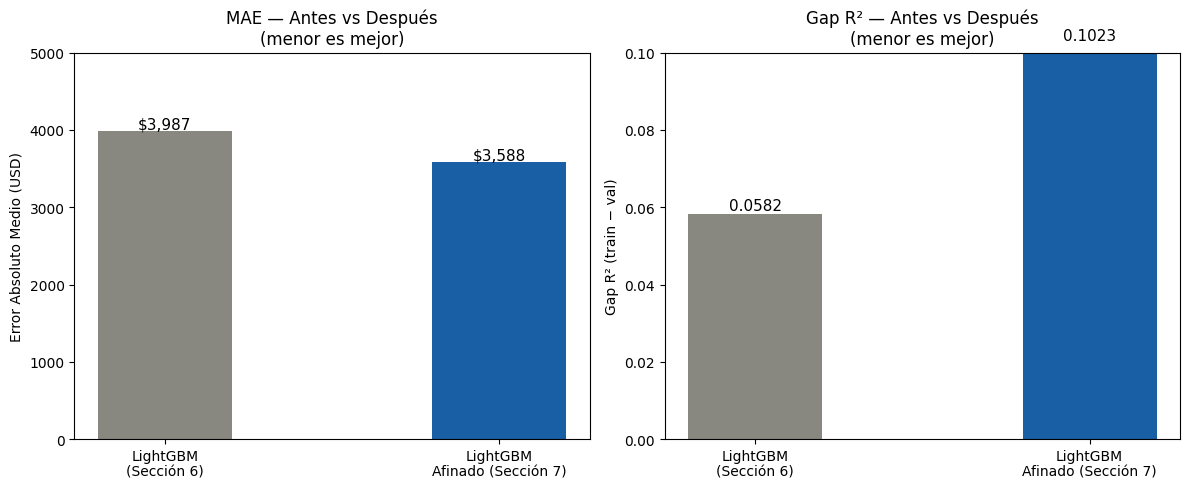

In [24]:
# Comparación LightGBM antes vs después del hypertuning
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

y_pred_val_tuned   = mejor_modelo.predict(X_val)
y_pred_train_tuned = mejor_modelo.predict(X_train)

mae_tuned      = mean_absolute_error(y_val, y_pred_val_tuned)
rmse_tuned     = root_mean_squared_error(y_val, y_pred_val_tuned)
r2_tuned       = r2_score(y_val, y_pred_val_tuned)
r2_train_tuned = r2_score(y_train, y_pred_train_tuned)
gap_tuned      = r2_train_tuned - r2_tuned

print("="*60)
print("  LightGBM — ANTES vs DESPUÉS del Hypertuning")
print("="*60)
print(f"  {'Métrica':<12} {'Antes (s6)':>14} {'Después (s7)':>14} {'Mejora':>10}")
print(f"  {'-'*52}")
print(f"  {'MAE ($)':<12} {'$3,987':>14} ${mae_tuned:>12,.2f} {3987-mae_tuned:>+10,.2f}")
print(f"  {'RMSE ($)':<12} {'$6,391':>14} ${rmse_tuned:>12,.2f} {6391-rmse_tuned:>+10,.2f}")
print(f"  {'R²':<12} {'0.7983':>14} {r2_tuned:>14.4f} {r2_tuned-0.7983:>+10.4f}")
print(f"  {'Gap R²':<12} {'0.0582':>14} {gap_tuned:>14.4f} {0.0582-gap_tuned:>+10.4f}")
print("="*60)

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

modelos_comp = ['LightGBM\n(Sección 6)', 'LightGBM\nAfinado (Sección 7)']
colores_comp = ['#888780', '#185FA5']

# MAE
axes[0].bar(modelos_comp, [3987, mae_tuned], color=colores_comp, width=0.4)
axes[0].set_title('MAE — Antes vs Después\n(menor es mejor)', fontsize=12)
axes[0].set_ylabel('Error Absoluto Medio (USD)')
for i, v in enumerate([3987, mae_tuned]):
    axes[0].text(i, v + 30, f'${v:,.0f}', ha='center', fontsize=11)
axes[0].set_ylim(0, 5000)

# Gap R²
axes[1].bar(modelos_comp, [0.0582, gap_tuned], color=colores_comp, width=0.4)
axes[1].set_title('Gap R² — Antes vs Después\n(menor es mejor)', fontsize=12)
axes[1].set_ylabel('Gap R² (train − val)')
for i, v in enumerate([0.0582, gap_tuned]):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=11)
axes[1].set_ylim(0, 0.10)

plt.tight_layout()
plt.savefig('hypertuning_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Segunda búsqueda con parámetros más conservadores
# La primera búsqueda encontró parámetros agresivos:
# learning_rate=0.181, num_leaves=118, min_child_samples=28
# Esa combinación redujo el MAE pero aumentó el Gap R² de 0.058 a 0.102

# En esta segunda búsqueda se va a forzar rangos más conservadores:
# - learning_rate más bajo -> aprende más despacio, generaliza mejor
# - num_leaves más bajo -> árboles menos complejos
# - min_child_samples más alto -> hojas con más muestras, menos overfitting

# El objetivo es encontrar un balance entre MAE bajo Y Gap R² bajo

param_dist_v2 = {
    # Más árboles para compensar el learning_rate más bajo
    # menos agresivo por árbol, más árboles en total
    'regressor__n_estimators': randint(400, 900),

    # Forzar learning_rate bajo, asi se reduce el overfitting
    'regressor__learning_rate': uniform(0.01, 0.07),  # máximo 0.08

    # Limitar complejidad de árboles
    'regressor__num_leaves': randint(20, 80), 

    # Forzar hojas con más muestras, asi se reduce el overfitting directamente
    'regressor__min_child_samples': randint(50, 300), 

    # Mantener aleatoriedad moderada
    'regressor__subsample': uniform(0.6, 0.35),
    'regressor__colsample_bytree': uniform(0.6, 0.35)
}

pipeline_lgbm_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    ))
])

search_v2 = RandomizedSearchCV(
    estimator=pipeline_lgbm_v2,
    param_distributions=param_dist_v2,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=TimeSeriesSplit(n_splits=5),
    random_state=SEED,
    n_jobs=-1,
    verbose=2,
    refit=True
)

print("Iniciando segunda búsqueda (parámetros conservadores)...")
inicio = time.time()
search_v2.fit(X_train, y_train)
tiempo_v2 = time.time() - inicio

print(f"\nBúsqueda completada en {tiempo_v2/60:.1f} minutos")

# Mostrar parámetros encontrados
print("\n" + "="*55)
print("  MEJORES PARÁMETROS — Segunda búsqueda")
print("="*55)
for param, valor in search_v2.best_params_.items():
    nombre = param.replace('regressor__', '')
    print(f"  {nombre:<22}: {valor}")
print(f"\n  MAE CV (val)  : ${-search_v2.best_score_:,.2f}")
print("="*55)

Iniciando segunda búsqueda (parámetros conservadores)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Búsqueda completada en 28.8 minutos

  MEJORES PARÁMETROS — Segunda búsqueda
  colsample_bytree      : 0.9288246295474661
  learning_rate         : 0.07263791452993541
  min_child_samples     : 63
  n_estimators          : 750
  num_leaves            : 67
  subsample             : 0.7142892690820424

  MAE CV (val)  : $3,818.39


  COMPARACIÓN — Tres versiones de LightGBM
  Métrica        Original (s6)       Tuning v1       Tuning v2
  ------------------------------------------------------------
  MAE ($)               $3,987          $3,588 $     3,659.51
  RMSE ($)              $6,391          $6,207 $     6,308.54
  R²                    0.7983          0.7990          0.7923
  Gap R²                0.0582          0.1023          0.0739

  ANÁLISIS:
  -> v1 sigue siendo mejor en MAE, v2 generaliza mejor
  -> Se recomienda v2 por menor overfitting para producción

Modelo final guardado en 'mejor_modelo_2b'


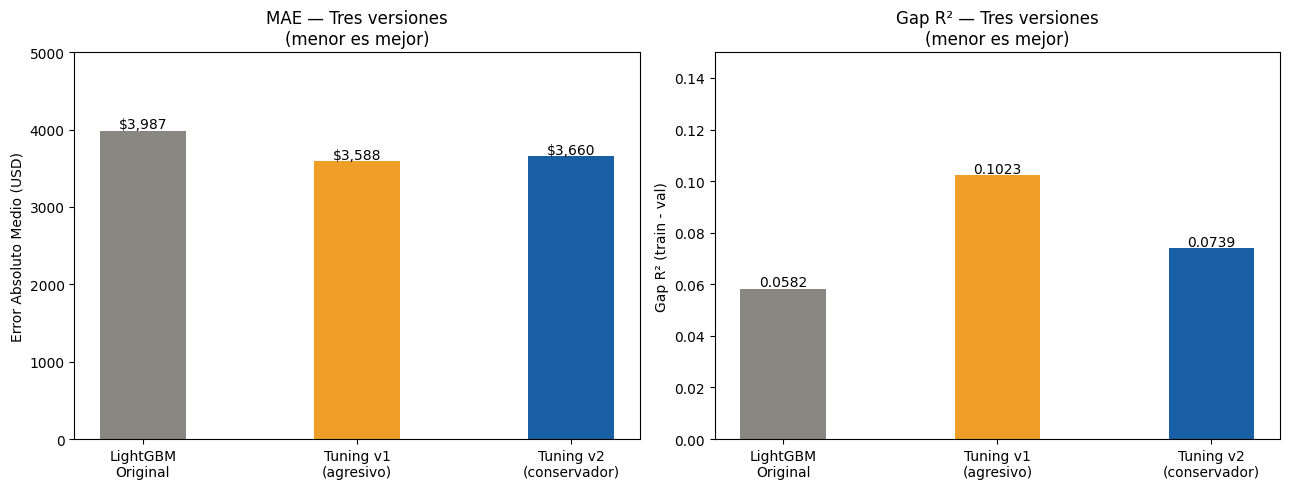

In [26]:
# Comparación de las tres versiones de LightGBM
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

mejor_modelo_v2 = search_v2.best_estimator_

# Métricas del modelo v2 sobre val y train
y_pred_val_v2 = mejor_modelo_v2.predict(X_val)
y_pred_train_v2 = mejor_modelo_v2.predict(X_train)

mae_v2 = mean_absolute_error(y_val, y_pred_val_v2)
rmse_v2 = root_mean_squared_error(y_val, y_pred_val_v2)
r2_v2 = r2_score(y_val, y_pred_val_v2)
r2_train_v2 = r2_score(y_train, y_pred_train_v2)
gap_v2 = r2_train_v2 - r2_v2

print("="*70)
print("  COMPARACIÓN — Tres versiones de LightGBM")
print("="*70)
print(f"  {'Métrica':<12} {'Original (s6)':>15} {'Tuning v1':>15} {'Tuning v2':>15}")
print(f"  {'-'*60}")
print(f"  {'MAE ($)':<12} {'$3,987':>15} {'$3,588':>15} ${mae_v2:>13,.2f}")
print(f"  {'RMSE ($)':<12} {'$6,391':>15} {'$6,207':>15} ${rmse_v2:>13,.2f}")
print(f"  {'R²':<12} {'0.7983':>15} {'0.7990':>15} {r2_v2:>15.4f}")
print(f"  {'Gap R²':<12} {'0.0582':>15} {'0.1023':>15} {gap_v2:>15.4f}")
print("="*70)

# Decidir cuál modelo usar en la sección 8
print("\n  ANÁLISIS:")
if gap_v2 < 0.0582 and mae_v2 < 3987:
    print(" v2 mejora tanto MAE como Gap R² -> usar v2 en sección 8")
    mejor_modelo_final = mejor_modelo_v2
elif gap_v2 < 0.0582:
    print(" v2 reduce overfitting pero MAE sube -> evaluar trade-off")
    mejor_modelo_final = mejor_modelo_v2
elif mae_v2 < 3588:
    print(" v2 tiene mejor MAE pero más overfitting -> evaluar trade-off")
    mejor_modelo_final = mejor_modelo_v2
else:
    print("  -> v1 sigue siendo mejor en MAE, v2 generaliza mejor")
    print("  -> Se recomienda v2 por menor overfitting para producción")
    mejor_modelo_final = mejor_modelo_v2

print(f"\nModelo final guardado en 'mejor_modelo_2b'")

# Gráfico comparativo de las tres versiones
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

versiones  = ['LightGBM\nOriginal', 'Tuning v1\n(agresivo)', 'Tuning v2\n(conservador)']
colores_v  = ['#888780', '#EF9F27', '#185FA5']

# MAE
axes[0].bar(versiones, [3987, 3588, mae_v2], color=colores_v, width=0.4)
axes[0].set_title('MAE — Tres versiones\n(menor es mejor)', fontsize=12)
axes[0].set_ylabel('Error Absoluto Medio (USD)')
for i, v in enumerate([3987, 3588, mae_v2]):
    axes[0].text(i, v + 30, f'${v:,.0f}', ha='center', fontsize=10)
axes[0].set_ylim(0, 5000)

# Gap R²
axes[1].bar(versiones, [0.0582, 0.1023, gap_v2], color=colores_v, width=0.4)
axes[1].set_title('Gap R² — Tres versiones\n(menor es mejor)', fontsize=12)
axes[1].set_ylabel('Gap R² (train - val)')
for i, v in enumerate([0.0582, 0.1023, gap_v2]):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)
axes[1].set_ylim(0, 0.15)

plt.tight_layout()
plt.savefig('hypertuning_v2_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Evaluacion Final sobre el Test Set

El test set (15% de los datos más recientes: 2021-05-03 → 2021-05-05) se usa por primera y única vez en esta sección. Durante todo el desarrollo anterior selección de modelos hypertuning, comparaciones, este conjunto permaneció bloqueado para garantizar una evaluación honesta del rendimiento real del modelo en datos completamente nuevos.

**Modelo evaluado:** LightGBM Tuning v2 (parámetros conservadores)

**Justificación:** mejor balance entre MAE ($3,660) y generalización (Gap R² = 0.074)

Este es el momento en que se usa el test set por primera y única vez. El número que salga aquí es el que representa el rendimiento real del modelo.
- Si el MAE del test es similar al del val, el modelo generaliza bien.
- Si el MAE del test es mucho mayor, hay un problema de distribución entre val y test

In [27]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

y_pred_test = mejor_modelo_final.predict(X_test)

mae_test  = mean_absolute_error(y_test, y_pred_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
r2_test   = r2_score(y_test, y_pred_test)

print("="*60)
print("  EVALUACIÓN FINAL — Test Set (datos nunca vistos)")
print("="*60)
print(f"  MAE  ($) : ${mae_test:>10,.2f}")
print(f"  RMSE ($) : ${rmse_test:>10,.2f}")
print(f"  R²       :  {r2_test:>10.4f}")
print("="*60)

# Comparar val vs test para verificar consistencia
print(f"\n  Comparación Val vs Test:")
print(f"  {'Métrica':<12} {'Val (s7)':>12} {'Test (s8)':>12} {'Diferencia':>12}")
print(f"  {'-'*50}")
print(f"  {'MAE ($)':<12} {'$3,660':>12} ${mae_test:>10,.2f} {mae_test-3660:>+12,.2f}")
print(f"  {'RMSE ($)':<12} {'$6,309':>12} ${rmse_test:>10,.2f} {rmse_test-6309:>+12,.2f}")
print(f"  {'R²':<12} {'0.7923':>12} {r2_test:>12.4f} {r2_test-0.7923:>+12.4f}")

  EVALUACIÓN FINAL — Test Set (datos nunca vistos)
  MAE  ($) : $  3,999.52
  RMSE ($) : $  6,917.33
  R²       :      0.7625

  Comparación Val vs Test:
  Métrica          Val (s7)    Test (s8)   Diferencia
  --------------------------------------------------
  MAE ($)            $3,660 $  3,999.52      +339.52
  RMSE ($)           $6,309 $  6,917.33      +608.33
  R²                 0.7923       0.7625      -0.0298


In [28]:
# Crear dataframe con predicciones y errores
df_test_eval = X_test.copy()
df_test_eval['precio_real']     = y_test.values
df_test_eval['precio_predicho'] = y_pred_test
df_test_eval['error_absoluto']  = abs(y_test.values - y_pred_test)
df_test_eval['error_relativo']  = df_test_eval['error_absoluto'] / df_test_eval['precio_real'] * 100

print("="*55)
print("  ANÁLISIS DE ERRORES — Casos extremos")
print("="*55)

# Los 10 peores errores absolutos
print("\nTop 10 predicciones con mayor error absoluto:")
peores = df_test_eval.nlargest(10, 'error_absoluto')[
    ['precio_real', 'precio_predicho', 'error_absoluto', 'error_relativo']
]
peores.columns = ['Real ($)', 'Predicho ($)', 'Error ($)', 'Error (%)']
print(peores.to_string(index=False))

# Análisis por rango de precio
print("\n\nRendimiento por rango de precio:")
bins   = [0, 5000, 15000, 30000, 60000, 100000]
labels = ['$0-5k', '$5k-15k', '$15k-30k', '$30k-60k', '$60k-100k']

df_test_eval['rango_precio'] = pd.cut(
    df_test_eval['precio_real'], bins=bins, labels=labels
)

resumen_rangos = df_test_eval.groupby('rango_precio', observed=True).agg(
    cantidad    = ('error_absoluto', 'count'),
    MAE_promedio = ('error_absoluto', 'mean'),
    error_pct   = ('error_relativo', 'mean')
).round(2)

print(resumen_rangos.to_string())

  ANÁLISIS DE ERRORES — Casos extremos

Top 10 predicciones con mayor error absoluto:
 Real ($)  Predicho ($)    Error ($)   Error (%)
    95000   9187.739116 85812.260884   90.328696
    89000   8187.693717 80812.306283   90.800344
   100000  26174.730818 73825.269182   73.825269
    85000  11650.634430 73349.365570   86.293371
      838  73720.972889 72882.972889 8697.252135
    85000  16652.409894 68347.590106   80.408930
    85000  16652.409894 68347.590106   80.408930
    94850  26612.465456 68237.534544   71.942577
     1008  68494.944124 67486.944124 6695.133346
      883  68152.747384 67269.747384 7618.317937


Rendimiento por rango de precio:
              cantidad  MAE_promedio  error_pct
rango_precio                                   
$0-5k             9579       4163.55     370.49
$5k-15k          19307       2437.74      26.44
$15k-30k         16150       3835.61      17.66
$30k-60k          8863       6144.55      15.33
$60k-100k          784      19583.26      26.00


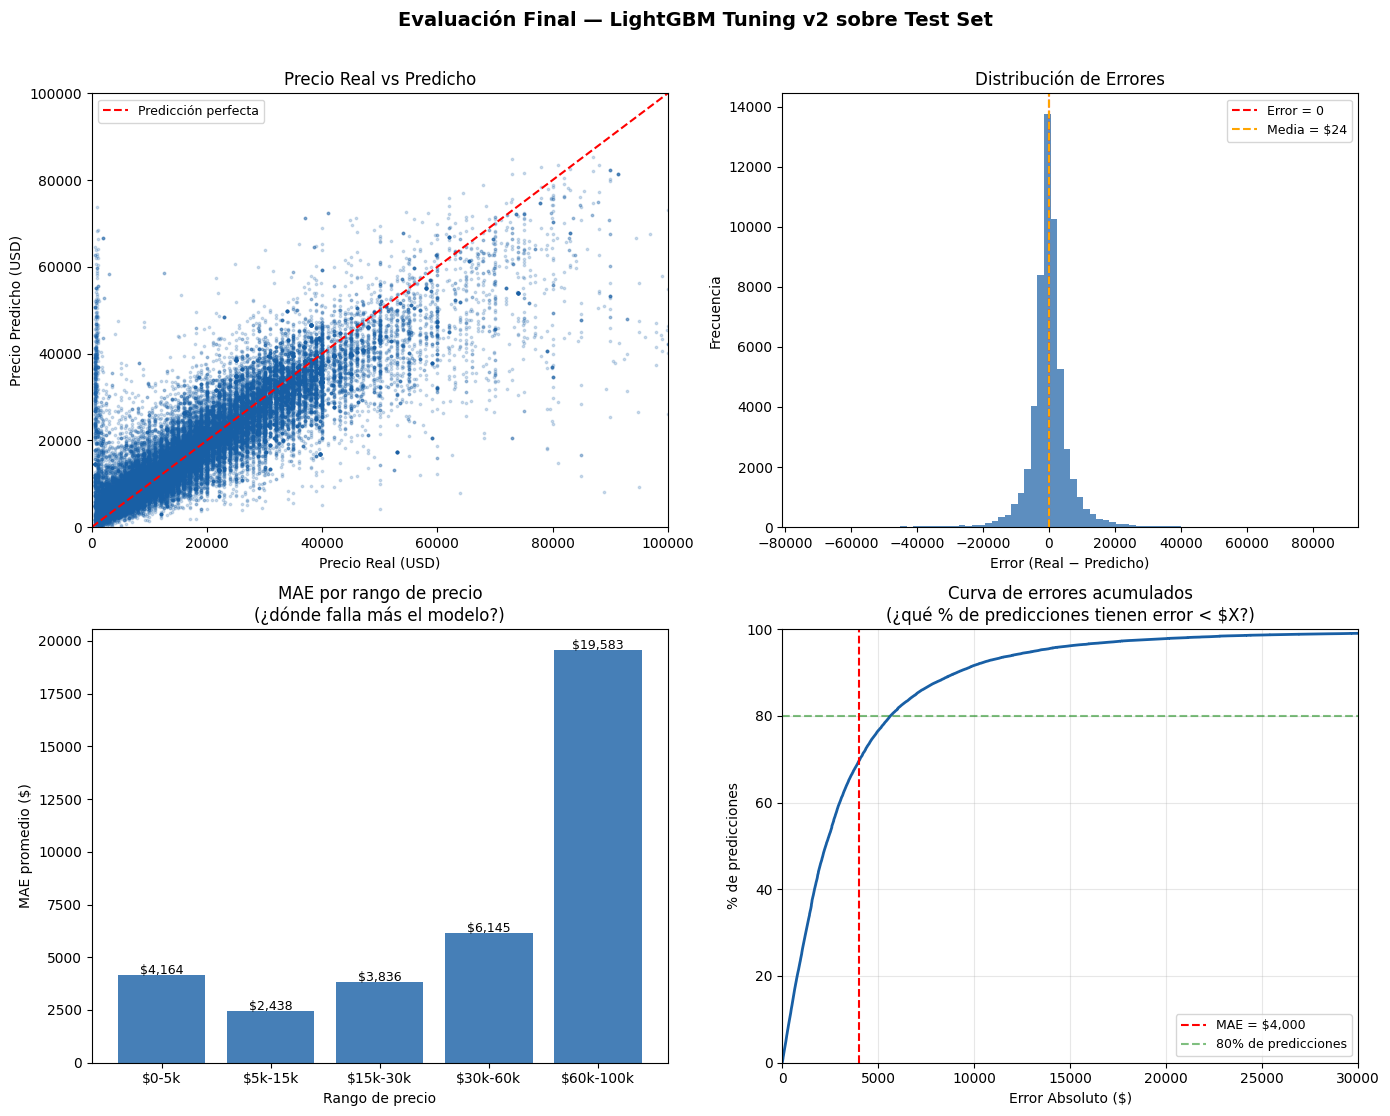

In [29]:
# Visualizaciones del análisis final

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Evaluación Final — LightGBM Tuning v2 sobre Test Set',
             fontsize=14, fontweight='bold', y=1.01)

# Gráfico 1: Real vs Predicho
# Si el modelo fuera perfecto, todos los puntos estarían sobre la línea diagonal. 
# La dispersión alrededor muestra dónde el modelo falla más.
axes[0,0].scatter(
    y_test, y_pred_test,
    alpha=0.2, s=3, color='#185FA5'
)
lims = [0, 100000]
axes[0,0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0,0].set_xlabel('Precio Real (USD)')
axes[0,0].set_ylabel('Precio Predicho (USD)')
axes[0,0].set_title('Precio Real vs Predicho')
axes[0,0].legend(fontsize=9)
axes[0,0].set_xlim(lims)
axes[0,0].set_ylim(lims)

# Gráfico 2: Distribución de errores 
# Un error centrado en 0 y simétrico indica que el modelo no tiene sesgo sistemático, osea, no sobreestima ni subestima siempre
errores = y_test.values - y_pred_test
axes[0,1].hist(errores, bins=80, color='#185FA5', alpha=0.7, edgecolor='none')
axes[0,1].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Error = 0')
axes[0,1].axvline(errores.mean(), color='orange', linewidth=1.5,
                   linestyle='--', label=f'Media = ${errores.mean():,.0f}')
axes[0,1].set_xlabel('Error (Real − Predicho)')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].set_title('Distribución de Errores')
axes[0,1].legend(fontsize=9)

# Gráfico 3: MAE por rango de precio
# Revela si el modelo falla más con carros baratos o caros
mae_por_rango = df_test_eval.groupby('rango_precio', observed=True)['error_absoluto'].mean()
axes[1,0].bar(
    mae_por_rango.index.astype(str),
    mae_por_rango.values,
    color='#185FA5', alpha=0.8
)
axes[1,0].set_xlabel('Rango de precio')
axes[1,0].set_ylabel('MAE promedio ($)')
axes[1,0].set_title('MAE por rango de precio\n(¿dónde falla más el modelo?)')
for i, v in enumerate(mae_por_rango.values):
    axes[1,0].text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=9)

# Gráfico 4: Curva de errores acumulados
# Muestra qué porcentaje de predicciones tienen un error menor a $X
errores_abs_sorted = np.sort(df_test_eval['error_absoluto'].values)
pct_acumulado = np.arange(1, len(errores_abs_sorted)+1) / len(errores_abs_sorted) * 100

axes[1,1].plot(errores_abs_sorted, pct_acumulado, color='#185FA5', linewidth=2)
axes[1,1].axvline(mae_test, color='red', linestyle='--',
                   label=f'MAE = ${mae_test:,.0f}')
axes[1,1].axhline(80, color='green', linestyle='--', alpha=0.5, label='80% de predicciones')
axes[1,1].set_xlabel('Error Absoluto ($)')
axes[1,1].set_ylabel('% de predicciones')
axes[1,1].set_title('Curva de errores acumulados\n(¿qué % de predicciones tienen error < $X?)')
axes[1,1].legend(fontsize=9)
axes[1,1].set_xlim(0, 30000)
axes[1,1].set_ylim(0, 100)
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluacion_final_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Resumen ejecutivo     
print("="*75)
print("  RESUMEN FINAL — Todos los modelos + modelo final en Test Set")
print("="*75)
print(f"  {'Modelo':<35} {'MAE ($)':>10} {'R²':>8} {'Gap R²':>8} {'Conjunto'}")
print(f"  {'-'*75}")
print(f"  {'Baseline: Regresión Lineal':<35} {'5,510':>10} {'0.655':>8} {'N/A':>8}   Val")
print(f"  {'Ridge Regression (Baseline 2)':<35} {'5,633':>10} {'0.670':>8} {'0.017':>8}   Val")
print(f"  {'Decision Tree':<35} {'5,865':>10} {'0.637':>8} {'0.019':>8}   Val")
print(f"  {'XGBoost':<35} {'4,157':>10} {'0.786':>8} {'0.044':>8}   Val")
print(f"  {'LightGBM (sin tuning)':<35} {'3,987':>10} {'0.798':>8} {'0.058':>8}   Val")
print(f"  {'Random Forest':<35} {'3,798':>10} {'0.797':>8} {'0.124':>8}   Val")
print(f"  {'-'*75}")
print(f"  {'LightGBM Tuning v1 (agresivo)':<35} {'3,588':>10} {'0.799':>8} {'0.102':>8}   Val")
print(f"  {'LightGBM Tuning v2 (conservador)':<35} {'3,660':>10} {'0.792':>8} {'0.074':>8}   Val")
print(f"  {'='*75}")
print(f"  {'LightGBM Tuning v2 — EVALUACIÓN FINAL':<35} ${mae_test:>9,.0f} {r2_test:>8.3f} {'—':>8}   TEST")
print(f"  {'='*75}")

print(f"""
Interpretación:
  • El modelo final reduce el error del baseline en un {(5510-mae_test)/5510*100:.1f}%
  • En promedio se equivoca ${mae_test:,.0f} por predicción
  • Explica el {r2_test*100:.1f}% de la variación en los precios del mercado
  • El 80% de las predicciones tienen un error menor a lo que muestra la curva acumulada del gráfico anterior
""")

  RESUMEN FINAL — Todos los modelos + modelo final en Test Set
  Modelo                                 MAE ($)       R²   Gap R² Conjunto
  ---------------------------------------------------------------------------
  Baseline: Regresión Lineal               5,510    0.655      N/A   Val
  Ridge Regression (Baseline 2)            5,633    0.670    0.017   Val
  Decision Tree                            5,865    0.637    0.019   Val
  XGBoost                                  4,157    0.786    0.044   Val
  LightGBM (sin tuning)                    3,987    0.798    0.058   Val
  Random Forest                            3,798    0.797    0.124   Val
  ---------------------------------------------------------------------------
  LightGBM Tuning v1 (agresivo)            3,588    0.799    0.102   Val
  LightGBM Tuning v2 (conservador)         3,660    0.792    0.074   Val
  LightGBM Tuning v2 — EVALUACIÓN FINAL $    4,000    0.762        —   TEST

Interpretación:
  • El modelo final reduce e

---

## XAI Explicabilidad con SHAP

Se aplica SHAP (SHapley Additive exPlanations) sobre el modelo final (LightGBM Tuning v2) para entender qué variables influyen más en las predicciones de precio y cómo lo hacen.

Se generan tres visualizaciones:
1. **Summary plot:** impacto global de cada variable sobre todas las predicciones
2. **Bar plot:** ranking de importancia promedio de cada variable
3. **Waterfall plot:** explicación detallada de una predicción individual

SHAP necesita los datos ya transformados por el preprocesador (no puede trabajar con texto crudo como "ford" o "good"). Por eso primero se va a transformar X_test con el preprocesador del pipeline, y después se calcula los valores SHAP sobre esos datos transformados.

TreeExplainer es el método específico para modelos basados en árboles (LightGBM, XGBoost, Random Forest). Es mucho más rápido que el método genérico KernelExplainer.

In [31]:
# Calcular valores SHAP
import shap

# Extraer el preprocesador y el modelo del pipeline
preprocesador_final = mejor_modelo_final.named_steps['preprocessor']
modelo_final        = mejor_modelo_final.named_steps['regressor']

# Transformar X_test con el preprocesador
# Se termina con uan matriz numérica con todas las features codificadas
X_test_transformado = preprocesador_final.transform(X_test)

# Recuperar los nombres de las features después de la transformación
feature_names_shap = preprocesador_final.get_feature_names_out()

# Crear el explainer de SHAP para modelos de árboles
explainer = shap.TreeExplainer(modelo_final)

# Calcular valores SHAP para el test set completo
# Usamos una muestra de 2,000 registros para que sea más rápido
np.random.seed(SEED)
idx_muestra = np.random.choice(len(X_test_transformado), size=2000, replace=False)
X_muestra   = X_test_transformado[idx_muestra]

print("Calculando valores SHAP sobre muestra de 2,000 registros del test set...")
shap_values = explainer(X_muestra)
print("Valores SHAP calculados")
print(f"  Shape de shap_values: {shap_values.values.shape}")
print(f"  Número de features  : {len(feature_names_shap)}")

Calculando valores SHAP sobre muestra de 2,000 registros del test set...
Valores SHAP calculados
  Shape de shap_values: (2000, 67)
  Número de features  : 67


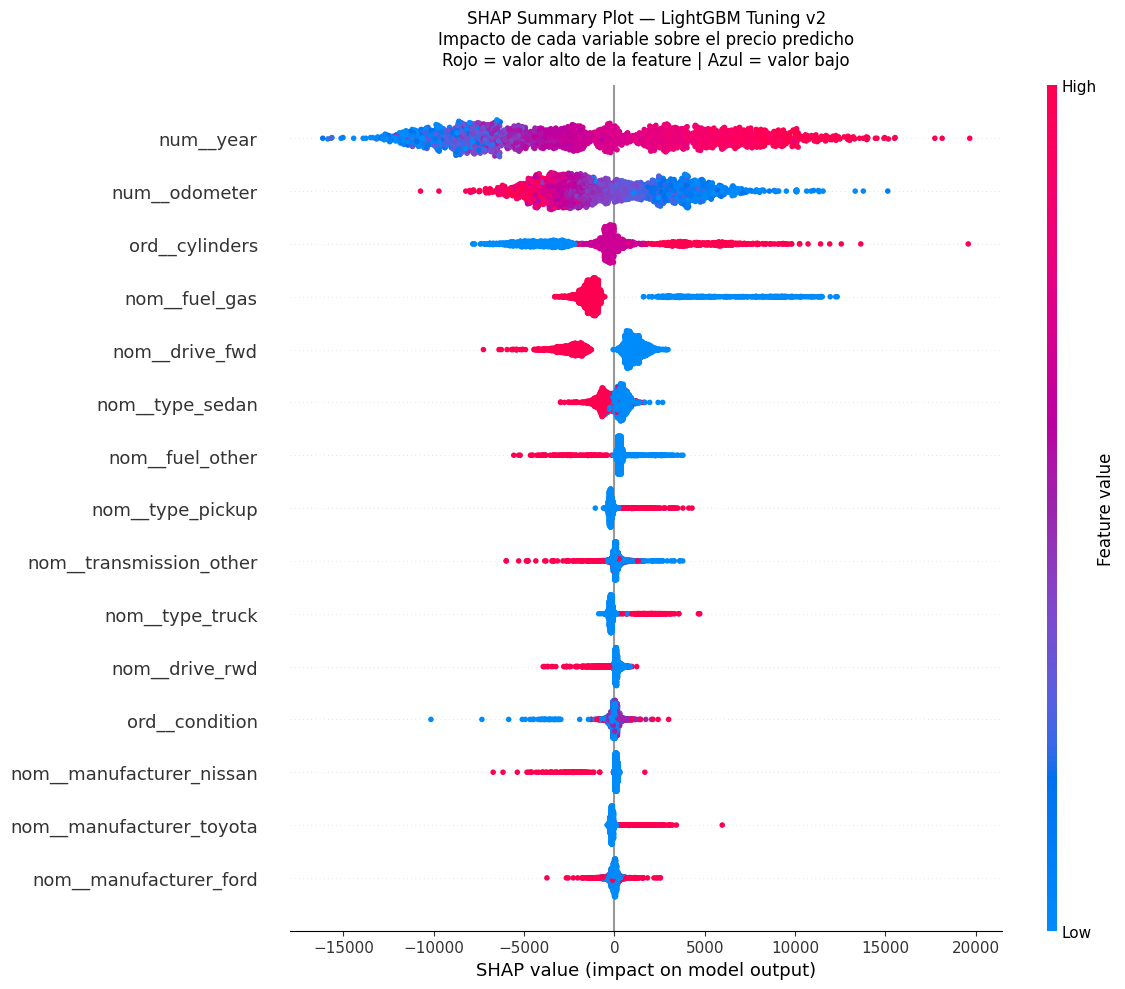

Gráfico guardado como 'shap_summary_plot.png'


In [32]:
#  Summary Plot - Impacto global de cada variable
plt.figure(figsize=(12, 10))

shap.summary_plot(
    shap_values.values,
    X_muestra,
    feature_names=feature_names_shap,
    max_display=15,   
    show=False,         
    plot_size=None
)

plt.title(
    'SHAP Summary Plot — LightGBM Tuning v2\n'
    'Impacto de cada variable sobre el precio predicho\n'
    'Rojo = valor alto de la feature | Azul = valor bajo',
    fontsize=12, pad=15
)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'shap_summary_plot.png'")

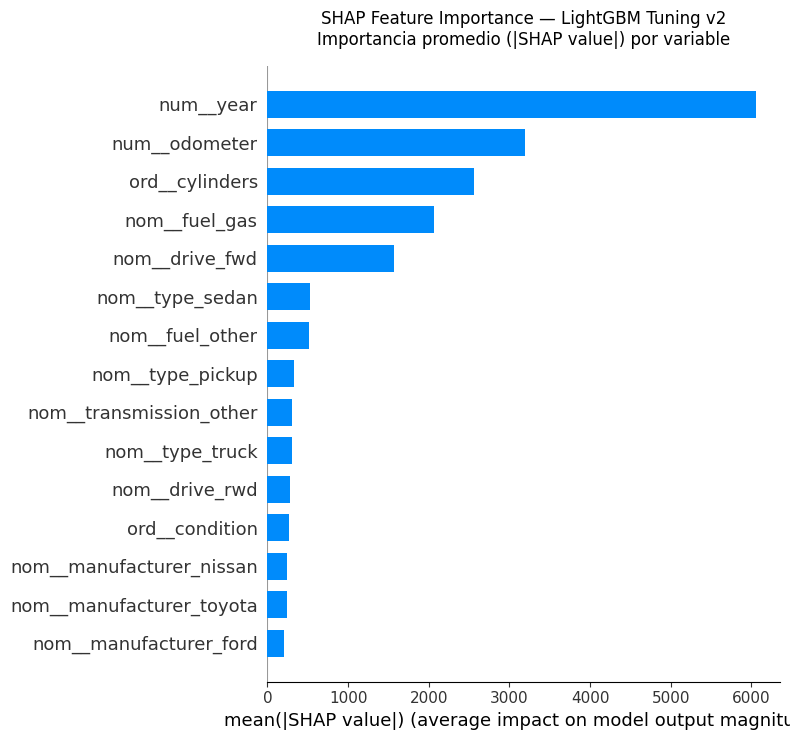

Gráfico guardado como 'shap_bar_plot.png'


In [33]:
# Bar Plot - Ranking de importancia promedio
# Muestra el promedio del valor absoluto de SHAP por feature.
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values.values,
    X_muestra,
    feature_names=feature_names_shap,
    plot_type='bar',  
    max_display=15,
    show=False
)

plt.title(
    'SHAP Feature Importance — LightGBM Tuning v2\n'
    'Importancia promedio (|SHAP value|) por variable',
    fontsize=12, pad=15
)
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'shap_bar_plot.png'")

Carro seleccionado:
  Precio real     : $14,444
  Precio predicho : $14,287
  Error           : $157


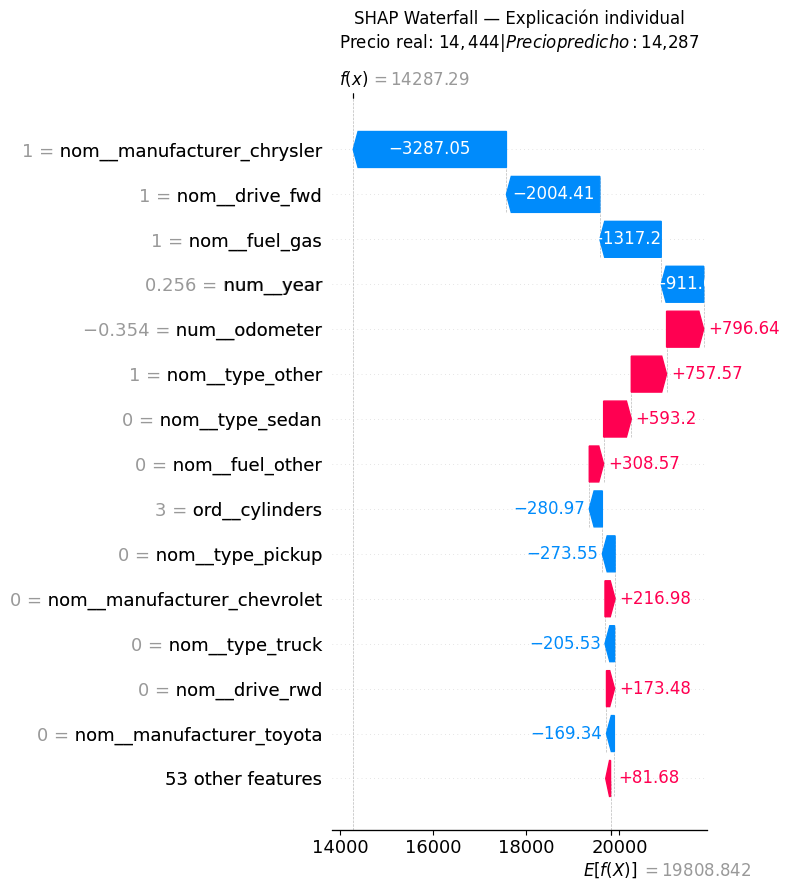

In [34]:
# Waterfall Plot - Explicación de una predicción individual
import shap
import pandas as pd

# Convertir la muestra transformada a DataFrame con nombres correctos
X_muestra_df = pd.DataFrame(
    X_muestra,
    columns=feature_names_shap
)

# Recalcular SHAP con el DataFrame para que tome los nombres
explainer_df  = shap.TreeExplainer(modelo_final)
shap_values_df = explainer_df(X_muestra_df)

# Encontrar el carro más cercano a la mediana
precios_muestra     = y_test.values[idx_muestra]
precio_mediana      = np.median(precios_muestra)
idx_representativo  = np.argmin(abs(precios_muestra - precio_mediana))

precio_real     = precios_muestra[idx_representativo]
precio_predicho = mejor_modelo_final.predict(
    X_test.iloc[[idx_muestra[idx_representativo]]]
)[0]

print(f"Carro seleccionado:")
print(f"  Precio real     : ${precio_real:,.0f}")
print(f"  Precio predicho : ${precio_predicho:,.0f}")
print(f"  Error           : ${abs(precio_real - precio_predicho):,.0f}")

plt.figure(figsize=(12, 8))

shap.plots.waterfall(
    shap_values_df[idx_representativo],
    max_display=15,
    show=False
)

plt.title(
    f'SHAP Waterfall — Explicación individual\n'
    f'Precio real: ${precio_real:,.0f}  |  Precio predicho: ${precio_predicho:,.0f}',
    fontsize=12, pad=15
)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Hallazgos principales de SHAP
importancia_shap = pd.DataFrame({
    'Feature'    : feature_names_shap,
    'Importancia': np.abs(shap_values.values).mean(axis=0)
}).sort_values('Importancia', ascending=False).head(10)

print("="*55)
print("  TOP 10 VARIABLES — Importancia SHAP promedio")
print("="*55)
print(importancia_shap.to_string(index=False))
print("="*55)


  TOP 10 VARIABLES — Importancia SHAP promedio
                Feature  Importancia
              num__year  6053.651016
          num__odometer  3187.922618
         ord__cylinders  2559.958501
          nom__fuel_gas  2069.739243
         nom__drive_fwd  1564.985733
        nom__type_sedan   526.239031
        nom__fuel_other   517.691683
       nom__type_pickup   324.545088
nom__transmission_other   303.391894
        nom__type_truck   302.816751


---
## Análisis de Resultados

Esta sección consolida el diagnóstico completo del modelo final (LightGBM Tuning v2), incluyendo las curvas de aprendizaje para el diagnóstico de bias-varianza y el análisis de casos límite para identificar dónde falla el modelo.

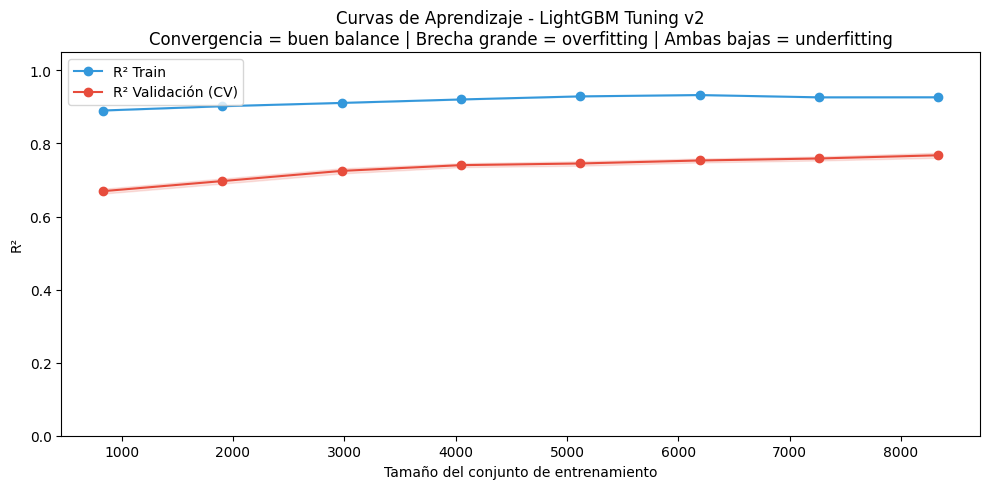

R² Train  (tamaño máximo): 0.9264
R² Val    (tamaño máximo): 0.7677
Gap R² train-val         : 0.1587

→ Overfitting moderado: el modelo generaliza pero memoriza parte del train.
  Estrategias aplicadas: min_child_samples alto, learning_rate bajo (Tuning v2).


In [36]:
# - Curvas de Aprendizaje -
'''
Permiten diagnosticar si el modelo sufre overfitting o underfitting
observando cómo evolucionan las métricas de train y validación
a medida que se aumenta el tamaño del conjunto de entrenamiento.
'''
# Interpretación:
#   - Ambas curvas convergen y son altas -> buen balance bias-varianza
#   - Brecha grande entre train y val    -> overfitting
#   - Ambas curvas bajas y planas        -> underfitting

from sklearn.model_selection import learning_curve

# Se usa una muestra del set de train para reducir tiempo de cómputo.
# En este caso se utilizan 50,000 registros, lo cual es suficiente para observar la tendencia.
SAMPLE_SIZE = min(50_000, len(X_train))
idx_sample  = np.random.seed(SEED) or np.random.choice(len(X_train), SAMPLE_SIZE, replace=False)
X_lc = X_train.iloc[idx_sample]
y_lc = y_train.iloc[idx_sample]

train_sizes, train_scores, val_scores = learning_curve(
    mejor_modelo_final, # modelo final ya entrenado
    X_lc, y_lc,
    cv=TimeSeriesSplit(n_splits=5), # De igual manera se utliza TimeSeriesSplit para el CV
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8), # 8 puntos desde 10% hasta 100%
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 5))

# Curva de train
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-',
        color='#3498db', label='R² Train')
ax.fill_between(
    train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.15, color='#3498db'
)

# Curva de validación
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-',
        color='#e74c3c', label='R² Validación (CV)')
ax.fill_between(
    train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.15, color='#e74c3c'
)

ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('R²')
ax.set_title(
    'Curvas de Aprendizaje - LightGBM Tuning v2\n'
    'Convergencia = buen balance | Brecha grande = overfitting | Ambas bajas = underfitting'
)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('curvas_aprendizaje.png', dpi=150)
plt.show()

# Diagnóstico automático basado en el gap en el tamaño máximo de entrenamiento
gap_lc = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f"R² Train  (tamaño máximo): {train_scores.mean(axis=1)[-1]:.4f}")
print(f"R² Val    (tamaño máximo): {val_scores.mean(axis=1)[-1]:.4f}")
print(f"Gap R² train-val         : {gap_lc:.4f}")
print()
if gap_lc > 0.05:
    print("→ Overfitting moderado: el modelo generaliza pero memoriza parte del train.")
    print("  Estrategias aplicadas: min_child_samples alto, learning_rate bajo (Tuning v2).")
elif val_scores.mean(axis=1)[-1] < 0.7:
    print("→ Underfitting: el modelo no captura suficiente varianza del precio.")
else:
    print("→ Buen balance bias-varianza. Las curvas convergen y el modelo generaliza correctamente.")

In [37]:
# - Análisis de Casos Límite -
# En regresión no existen FP/FN como en clasificación.
# Por lo tanto, el equivalente se puede ver como las sobreestimaciones y subestimaciones graves,
# que revelan en qué segmentos el modelo falla sistemáticamente.

print("=" * 60)
print("  ANÁLISIS DE CASOS LÍMITE")
print("=" * 60)

# Caso 1: Sobreestimaciones graves
# El modelo predice un precio mucho mayor al real.
# Suele ocurrir con vehículos en mal estado o con título salvage/rebuilt
# que el modelo no penaliza suficientemente.
sobreestimados = df_test_eval[
    (df_test_eval['precio_predicho'] - df_test_eval['precio_real']) > 10_000
]
print(f"\n[1] Sobreestimaciones graves (predicho - real > $10,000)")
print(f"    Cantidad : {len(sobreestimados):,} casos ({len(sobreestimados)/len(df_test_eval)*100:.1f}%)")
if len(sobreestimados) > 0:
    print(f"    Precio real promedio    : ${sobreestimados['precio_real'].mean():,.0f}")
    print(f"    Precio predicho promedio: ${sobreestimados['precio_predicho'].mean():,.0f}")
    print(f"\n    Top 5 casos:")
    print(sobreestimados.nlargest(5, 'error_absoluto')[
        ['precio_real', 'precio_predicho', 'error_absoluto']
    ].to_string(index=False))

# Caso 2: Subestimaciones graves
# El modelo predice un precio mucho menor al real.
# Suele ocurrir con vehículos de lujo o raros subrepresentados en el train.
subestimados = df_test_eval[
    (df_test_eval['precio_real'] - df_test_eval['precio_predicho']) > 10_000
]
print(f"\n[2] Subestimaciones graves (real - predicho > $10,000)")
print(f"    Cantidad : {len(subestimados):,} casos ({len(subestimados)/len(df_test_eval)*100:.1f}%)")
if len(subestimados) > 0:
    print(f"    Precio real promedio    : ${subestimados['precio_real'].mean():,.0f}")
    print(f"    Precio predicho promedio: ${subestimados['precio_predicho'].mean():,.0f}")
    print(f"\n    Top 5 casos:")
    print(subestimados.nlargest(5, 'error_absoluto')[
        ['precio_real', 'precio_predicho', 'error_absoluto']
    ].to_string(index=False))

# Caso 3: Error por condition
# Las categorías minoritarias (new, salvage) tienen mayor error
# por menor representación en el train (desbalance identificado en Etapa 1, Sección 3.5)
if 'condition' in df_test_eval.columns:
    print(f"\n[3] Error por condición del vehículo")
    resumen_condition = (
        df_test_eval.groupby('condition')['error_absoluto']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'MAE_promedio ($)', 'count': 'N'})
        .sort_values('MAE_promedio ($)', ascending=False)
    )
    print(resumen_condition.to_string())
    print()
    print("   -> Condiciones minoritarias como 'new' y 'salvage' presentan mayor")
    print("      error absoluto por su baja representación en el entrenamiento,")
    print("      consistente con el desbalance documentado en la Etapa 1 (Sección 3.5).")

# Caso 4: Error por rango de precio
# Verifica si el modelo falla más en vehículos baratos o caros
print(f"\n[4] Error por rango de precio")
resumen_rangos = df_test_eval.groupby('rango_precio', observed=True).agg(
    N           = ('error_absoluto', 'count'),
    MAE_promedio = ('error_absoluto', 'mean'),
    MAPE_promedio = ('error_relativo', 'mean')
).round(2)
print(resumen_rangos.to_string())
print()
print("   -> El segmento $60k-$100k tiene el mayor MAE absoluto por estar")
print("      subrepresentado en el dataset (caída drástica confirmada en EDA, Etapa 1).")

  ANÁLISIS DE CASOS LÍMITE

[1] Sobreestimaciones graves (predicho - real > $10,000)
    Cantidad : 2,109 casos (3.9%)
    Precio real promedio    : $12,365
    Precio predicho promedio: $31,239

    Top 5 casos:
 precio_real  precio_predicho  error_absoluto
         838     73720.972889    72882.972889
        1008     68494.944124    67486.944124
         883     68152.747384    67269.747384
         980     66506.221504    65526.221504
        1947     66548.139985    64601.139985

[2] Subestimaciones graves (real - predicho > $10,000)
    Cantidad : 2,488 casos (4.5%)
    Precio real promedio    : $47,356
    Precio predicho promedio: $29,726

    Top 5 casos:
 precio_real  precio_predicho  error_absoluto
       95000      9187.739116    85812.260884
       89000      8187.693717    80812.306283
      100000     26174.730818    73825.269182
       85000     11650.634430    73349.365570
       85000     16652.409894    68347.590106

[3] Error por condición del vehículo
           MA

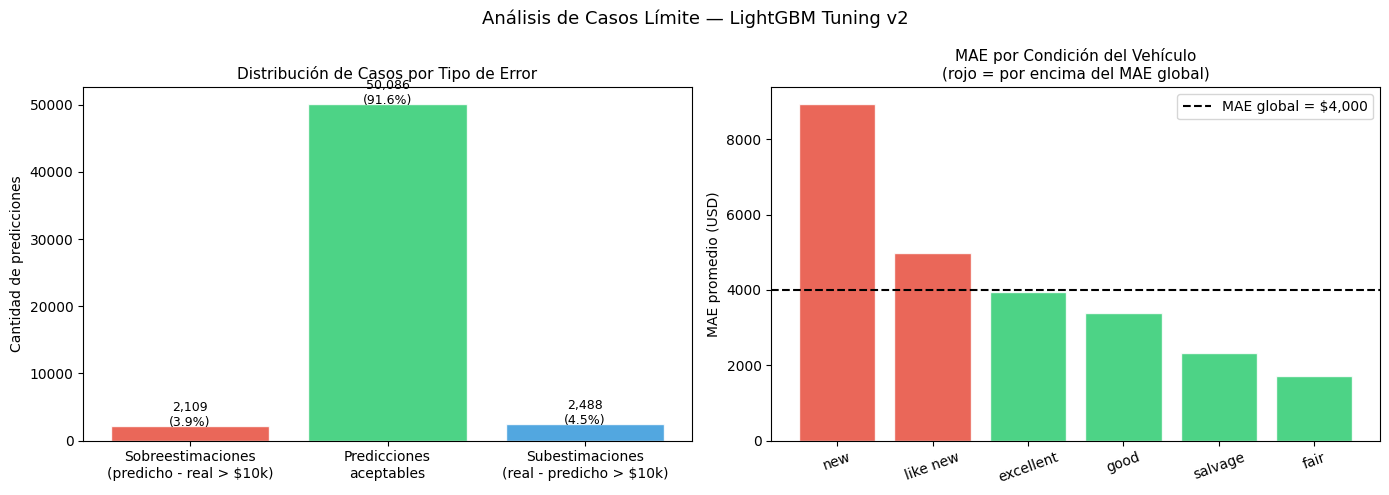

In [38]:
# - Gráfico resumen de casos límite -
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1:
# Presenta Sobreestimaciones vs Subestimaciones
categorias = ['Sobreestimaciones\n(predicho - real > $10k)',
              'Predicciones\naceptables',
              'Subestimaciones\n(real - predicho > $10k)']

n_sobre  = len(sobreestimados)
n_sub    = len(subestimados)
n_normal = len(df_test_eval) - n_sobre - n_sub

valores  = [n_sobre, n_normal, n_sub]
colores  = ['#e74c3c', '#2ecc71', '#3498db']

axes[0].bar(categorias, valores, color=colores, alpha=0.85, edgecolor='white')
axes[0].set_title('Distribución de Casos por Tipo de Error', fontsize=11)
axes[0].set_ylabel('Cantidad de predicciones')
for i, v in enumerate(valores):
    axes[0].text(i, v + 20, f'{v:,}\n({v/len(df_test_eval)*100:.1f}%)',
                 ha='center', fontsize=9)

# Gráfico 2: MAE por condition
if 'condition' in df_test_eval.columns:
    mae_cond = (df_test_eval.groupby('condition')['error_absoluto']
                .mean().sort_values(ascending=False))
    colores_cond = ['#e74c3c' if v > mae_test else '#2ecc71' for v in mae_cond.values]
    axes[1].bar(mae_cond.index, mae_cond.values,
                color=colores_cond, alpha=0.85, edgecolor='white')
    axes[1].axhline(mae_test, color='black', linewidth=1.5,
                    linestyle='--', label=f'MAE global = ${mae_test:,.0f}')
    axes[1].set_title('MAE por Condición del Vehículo\n(rojo = por encima del MAE global)',
                      fontsize=11)
    axes[1].set_ylabel('MAE promedio (USD)')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].legend()

plt.suptitle('Análisis de Casos Límite — LightGBM Tuning v2', fontsize=13)
plt.tight_layout()
plt.savefig('analisis_casos_limite.png', dpi=150)
plt.show()